# Proyecto PENGWIN - Notebook acumulativo

Este es el unico notebook del proyecto. Reune de forma progresiva la carga del dataset medico `.mha`, verificacion imagen-label, splits fijos, ventaneo HU, EDA, visualizacion 3D, preparacion de datos y targets, y las etapas de modelado que se incorporen en los siguientes avances.

La ejecucion es reproducible desde la raiz del repositorio y utiliza exclusivamente rutas relativas. Los datos locales deben estar en `data_mha/`.

## 1. Librerias base

Se importan las librerias necesarias para trabajar con rutas, tablas, volumenes medicos, arreglos numericos y graficas.

In [100]:
from pathlib import Path
import pandas as pd
import SimpleITK as sitk
import numpy as np
import random
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import time
from matplotlib.patches import Rectangle
import torch.nn.functional as F

## 2. Configuracion de rutas reproducibles

Todas las rutas se construyen desde `Path.cwd()`, es decir, desde la raiz del repositorio. Esto evita rutas absolutas de un computador especifico y permite que cualquier integrante ejecute el notebook si conserva la estructura esperada.

In [101]:
BASE_DIR = Path.cwd()

DATA_MHA_DIR = BASE_DIR / "data_mha"

IMAGE_DIRS = [
    DATA_MHA_DIR / "PENGWIN_CT_train_images_part1",
    DATA_MHA_DIR / "PENGWIN_CT_train_images_part2",
]

LABELS_DIR = DATA_MHA_DIR / "PENGWIN_CT_train_labels"
LABEL_DIR = LABELS_DIR  # Alias para compatibilidad con celdas anteriores
SPLITS_DIR = BASE_DIR / "splits"
EVIDENCE_DIR = BASE_DIR / "evidencias"
GENERATED_DATA_DIR = EVIDENCE_DIR / "datos"

SPLITS_DIR.mkdir(exist_ok=True)
EVIDENCE_DIR.mkdir(exist_ok=True)
GENERATED_DATA_DIR.mkdir(parents=True, exist_ok=True)


def to_repo_relative(path):
    """Guarda rutas portables dentro del repositorio."""
    path = Path(path)
    try:
        return path.relative_to(BASE_DIR).as_posix()
    except ValueError:
        return path.as_posix()


def resolve_repo_path(path):
    """Permite leer rutas relativas o absolutas sin romper compatibilidad."""
    path = Path(path)
    if path.is_absolute():
        return path
    return BASE_DIR / path


## 3. Conteo inicial de archivos `.mha`

Se buscan las imagenes CT y las mascaras/labels locales. En esta entrega los datos pesados no se suben a GitHub; cada integrante debe tenerlos en `data_mha/`.

In [102]:
image_files = []

for image_dir in IMAGE_DIRS:
    image_files.extend(image_dir.glob("*.mha"))

image_files = sorted(image_files)
label_files = sorted(LABELS_DIR.glob("*.mha"))

print("RESUMEN DEL DATASET")


print(f"Imágenes encontradas: {len(image_files)}")
print(f"Labels encontrados:   {len(label_files)}")

RESUMEN DEL DATASET
Imágenes encontradas: 100
Labels encontrados:   100


## 4. Extraccion de IDs de casos

Se extraen los IDs desde los nombres de archivo para comparar imagenes y labels sin depender de rutas completas.

In [103]:
image_ids = {
    file.stem
    for file in image_files
}

label_ids = {
    file.stem
    for file in label_files
}

## 5. Validacion de correspondencia imagen-label

Se comprueba que cada imagen tenga su label y que no existan labels sin imagen. Esta validacion es la base del dataset curado.

In [104]:
images_without_labels = sorted(image_ids - label_ids)
labels_without_images = sorted(label_ids - image_ids)

common_ids = sorted(image_ids & label_ids)

print("VALIDACIÓN DE CORRESPONDENCIA")

print(f"Casos con imagen + label: {len(common_ids)}")

print(
    f"Imágenes sin label:       {len(images_without_labels)}"
)

print(
    f"Labels sin imagen:        {len(labels_without_images)}"
)


if images_without_labels:
    print("\nImágenes sin label:")
    for case_id in images_without_labels:
        print(f"  - {case_id}")


if labels_without_images:
    print("\nLabels sin imagen:")
    for case_id in labels_without_images:
        print(f"  - {case_id}")


VALIDACIÓN DE CORRESPONDENCIA
Casos con imagen + label: 100
Imágenes sin label:       0
Labels sin imagen:        0


## 6. Construccion del dataset curado

Se crea una tabla con `case_id`, ruta relativa de imagen y ruta relativa de label. Las rutas se guardan relativas al repositorio para mantener reproducibilidad entre computadores.

In [105]:
dataset = []

for case_id in common_ids:

    # Buscar la imagen en todas las partes
    image_path = None

    for image_dir in IMAGE_DIRS:
        possible_path = image_dir / f"{case_id}.mha"

        if possible_path.exists():
            image_path = possible_path
            break

    # Ruta del label
    label_path = LABELS_DIR / f"{case_id}.mha"

    # Verificar que ambos existan
    if image_path is not None and label_path.exists():

        dataset.append({
            "case_id": case_id,
            "image_path": to_repo_relative(image_path),
            "label_path": to_repo_relative(label_path)
        })


df = pd.DataFrame(dataset)
df


,case_id,image_path,label_path
0,001,data_mha/PENGWIN_CT_train_images_part1/001.mha,data_mha/PENGWIN_CT_train_labels/001.mha
1,002,data_mha/PENGWIN_CT_train_images_part1/002.mha,data_mha/PENGWIN_CT_train_labels/002.mha
2,003,data_mha/PENGWIN_CT_train_images_part1/003.mha,data_mha/PENGWIN_CT_train_labels/003.mha
3,004,data_mha/PENGWIN_CT_train_images_part1/004.mha,data_mha/PENGWIN_CT_train_labels/004.mha
4,005,data_mha/PENGWIN_CT_train_images_part1/005.mha,data_mha/PENGWIN_CT_train_labels/005.mha
...,...,...,...
95,096,data_mha/PENGWIN_CT_train_images_part2/096.mha,data_mha/PENGWIN_CT_train_labels/096.mha
96,097,data_mha/PENGWIN_CT_train_images_part2/097.mha,data_mha/PENGWIN_CT_train_labels/097.mha
97,098,data_mha/PENGWIN_CT_train_images_part2/098.mha,data_mha/PENGWIN_CT_train_labels/098.mha
98,099,data_mha/PENGWIN_CT_train_images_part2/099.mha,data_mha/PENGWIN_CT_train_labels/099.mha


## 7. Exportacion de `dataset.csv`

Se guarda el dataset curado en `splits/dataset.csv`. Este archivo queda versionado en GitHub porque contiene rutas ligeras y reproducibles, no datos pesados.

In [106]:
dataset_path = SPLITS_DIR / "dataset.csv"

df.to_csv(
    dataset_path,
    index=False
)

print()
print(f"Dataset curado guardado en:")
print(to_repo_relative(dataset_path))


Dataset curado guardado en:
splits/dataset.csv


## 8. Verificacion tecnica de volumenes `.mha`

Se cargan imagen y label con SimpleITK para verificar dimensiones, spacing, origen y direccion. Esto confirma que las mascaras corresponden fisicamente con las tomografias.

In [107]:
records = []

for _, row in df.iterrows():

    image = sitk.ReadImage(str(resolve_repo_path(row["image_path"])))
    label = sitk.ReadImage(str(resolve_repo_path(row["label_path"])))

    records.append({
        "case_id": row["case_id"],

        # Imagen
        "image_dimension": image.GetDimension(),
        "image_size": image.GetSize(),
        "image_spacing": image.GetSpacing(),

        # Label
        "label_dimension": label.GetDimension(),
        "label_size": label.GetSize(),
        "label_spacing": label.GetSpacing(),

        # Verificaciones
        "same_size": image.GetSize() == label.GetSize(),
        "same_spacing": image.GetSpacing() == label.GetSpacing(),
        "same_direction": image.GetDirection() == label.GetDirection(),
        "same_origin": image.GetOrigin() == label.GetOrigin()
    })

verification_df = pd.DataFrame(records)

verification_df.head(20)


,case_id,image_dimension,image_size,image_spacing,label_dimension,label_size,label_spacing,same_size,same_spacing,same_direction,same_origin
0,001,3,"(512, 512, 401)","(0.78125, 0.78125, 0.800000011920929)",3,"(512, 512, 401)","(0.78125, 0.78125, 0.800000011920929)",True,True,True,True
1,002,3,"(413, 276, 337)","(0.82421875, 0.82421875, 0.800000011920929)",3,"(413, 276, 337)","(0.82421875, 0.82421875, 0.800000011920929)",True,True,True,True
2,003,3,"(512, 381, 285)","(0.759765625, 0.759765625, 1.0)",3,"(512, 381, 285)","(0.759765625, 0.759765625, 1.0)",True,True,True,True
3,004,3,"(386, 254, 224)","(0.84375, 0.84375, 1.0)",3,"(386, 254, 224)","(0.84375, 0.84375, 1.0)",True,True,True,True
4,005,3,"(512, 512, 312)","(0.896484375, 0.896484375, 1.0)",3,"(512, 512, 312)","(0.896484375, 0.896484375, 1.0)",True,True,True,True
5,006,3,"(426, 279, 283)","(0.8125, 0.8125, 1.0)",3,"(426, 279, 283)","(0.8125, 0.8125, 1.0)",True,True,True,True
6,007,3,"(512, 512, 317)","(0.8359375, 0.8359375, 1.0)",3,"(512, 512, 317)","(0.8359375, 0.8359375, 1.0)",True,True,True,True
7,008,3,"(512, 512, 335)","(0.7421875, 0.7421875, 0.800000011920929)",3,"(512, 512, 335)","(0.7421875, 0.7421875, 0.800000011920929)",True,True,True,True
8,009,3,"(415, 245, 303)","(0.8125, 0.8125, 0.8000000715255737)",3,"(415, 245, 303)","(0.8125, 0.8125, 0.8000000715255737)",True,True,True,True
9,010,3,"(512, 512, 350)","(0.9459999799728394, 0.9459999799728394, 0.798...",3,"(512, 512, 350)","(0.9459999799728394, 0.9459999799728394, 0.798...",True,True,True,True


## 9. Resumen de consistencia del dataset

Se resumen las verificaciones anteriores para confirmar que el dataset local esta completo y alineado.

In [108]:
print("Casos:", len(verification_df))

print("\nDimensiones de las imágenes:")
print(verification_df["image_dimension"].value_counts())

print("\nDimensiones de los labels:")
print(verification_df["label_dimension"].value_counts())

print("\nTamaños CT-label iguales:")
print(verification_df["same_size"].value_counts())

print("\nSpacing CT-label iguales:")
print(verification_df["same_spacing"].value_counts())

Casos: 100

Dimensiones de las imágenes:
image_dimension
3    100
Name: count, dtype: int64

Dimensiones de los labels:
label_dimension
3    100
Name: count, dtype: int64

Tamaños CT-label iguales:
same_size
True    100
Name: count, dtype: int64

Spacing CT-label iguales:
same_spacing
True    100
Name: count, dtype: int64


## 10. Conteo inicial de fragmentos por caso

A partir de las labels se cuenta cuantas etiquetas diferentes aparecen en cada caso, excluyendo el fondo. Esto da una primera idea de la complejidad del dataset.

In [109]:
frag_counts = []

for _, row in df.iterrows():
    label_img = sitk.ReadImage(str(resolve_repo_path(row["label_path"])))
    label_vol = sitk.GetArrayFromImage(label_img)
    n_fragments = len(np.unique(label_vol)) - 1  # excluir fondo (label 0)
    frag_counts.append(n_fragments)

df["n_fragments"] = frag_counts

print("Distribucion de numero de fragmentos por caso:")
print(df["n_fragments"].describe())
print("\nConteo de valores (cuantos casos tienen cada n de fragmentos):")
print(df["n_fragments"].value_counts().sort_index())

Distribucion de numero de fragmentos por caso:
count    100.000000
mean       5.750000
std        1.217507
min        3.000000
25%        5.000000
50%        6.000000
75%        7.000000
max        9.000000
Name: n_fragments, dtype: float64

Conteo de valores (cuantos casos tienen cada n de fragmentos):
n_fragments
3     1
4    13
5    32
6    28
7    18
8     6
9     2
Name: count, dtype: int64


## 11. Splits fijos

Se usa una particion 75/5/20: 75 casos para entrenamiento, 5 para validacion y 20 para test. La semilla fija permite reproducir siempre los mismos splits.

In [110]:
from sklearn.model_selection import train_test_split

SEED = 42


def complexity_bin(n_fragments):
    if n_fragments <= 4:
        return "baja"
    if n_fragments <= 6:
        return "media"
    return "alta"

split_source = df[["case_id", "image_path", "label_path", "n_fragments"]].copy()
split_source["complexity"] = split_source["n_fragments"].apply(complexity_bin)

train_val_df, test_df = train_test_split(
    split_source,
    test_size=20,
    random_state=SEED,
    shuffle=True,
    stratify=split_source["complexity"],
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=5,
    random_state=SEED,
    shuffle=True,
    stratify=train_val_df["complexity"],
)

splits = {
    "train": train_df.sort_values("case_id"),
    "val": val_df.sort_values("case_id"),
    "test": test_df.sort_values("case_id"),
}

for name, split_df in splits.items():
    (SPLITS_DIR / f"{name}.txt").write_text("\n".join(split_df["case_id"].tolist()) + "\n")

split_dataset = []
for name, split_df in splits.items():
    temp = split_df.copy()
    temp.insert(1, "split", name)
    split_dataset.append(temp)

split_dataset = pd.concat(split_dataset, ignore_index=True).sort_values("case_id")
split_dataset.to_csv(SPLITS_DIR / "dataset.csv", index=False)

print("Splits fijos con semilla:", SEED)
print(split_dataset["split"].value_counts().reindex(["train", "val", "test"]))
print("\nDistribucion por complejidad:")
print(split_dataset.groupby(["split", "complexity"]).size().unstack(fill_value=0))


Splits fijos con semilla: 42
split
train    75
val       5
test     20
Name: count, dtype: int64

Distribucion por complejidad:
complexity  alta  baja  media
split                        
test           5     3     12
train         20    10     45
val            1     1      3


## 12. Ventaneo HU para visualizacion de hueso

Se define una ventana osea aproximada usando centro 400 HU y ancho 1800 HU. El objetivo es redistribuir intensidades para resaltar hueso y justificar el preprocesamiento con valores HU.

In [111]:
def load_mha(path):
    image = sitk.ReadImage(str(resolve_repo_path(path)))
    volume = sitk.GetArrayFromImage(image).astype(np.float32)  # orden (z, y, x)
    spacing = tuple(float(value) for value in image.GetSpacing())  # (x, y, z) mm
    return volume, spacing


def apply_hu_window(volume, window_center=400, window_width=1800):
    low = window_center - window_width / 2
    high = window_center + window_width / 2
    windowed = np.clip(volume, low, high)
    windowed = (windowed - low) / (high - low)
    return windowed

# prueba rapida sobre un caso MHA
volume, spacing = load_mha(df.loc[0, "image_path"])
windowed = apply_hu_window(volume)
print(f"Caso {df.loc[0, 'case_id']}: spacing={spacing}, "
      f"rango original=({volume.min():.1f}, {volume.max():.1f}), "
      f"rango ventaneado=({windowed.min():.2f}, {windowed.max():.2f})")

Caso 001: spacing=(0.78125, 0.78125, 0.800000011920929), rango original=(-1023.0, 2775.0), rango ventaneado=(0.00, 1.00)


## 13. Comparacion visual antes y despues del ventaneo

Se muestra un corte del caso 001 sin ventanear y con ventana osea. Esta evidencia ayuda a explicar por que el ventaneo mejora la discriminacion visual del hueso.

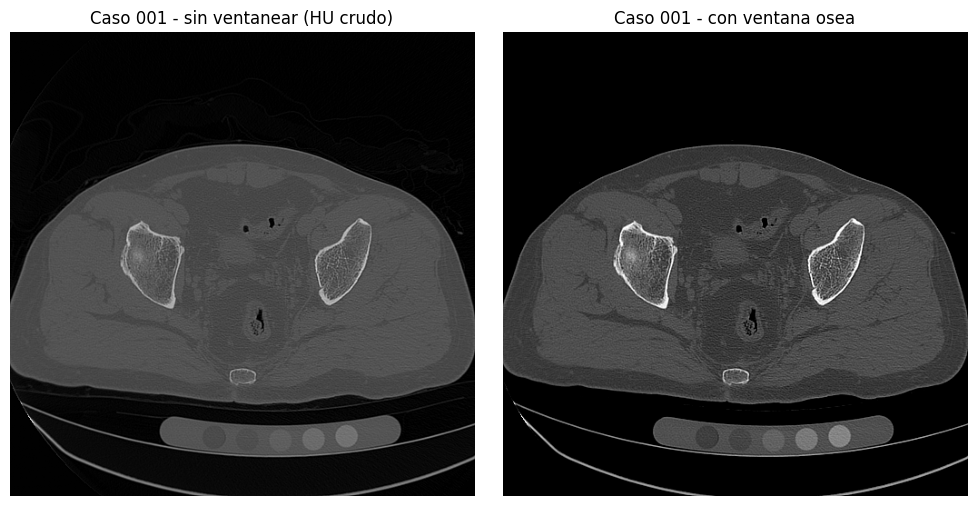

In [112]:
case_id = "001"
row = df[df["case_id"] == case_id].iloc[0]

volume, spacing = load_mha(row["image_path"])
windowed = apply_hu_window(volume)

# SimpleITK entrega el volumen en orden (z, y, x)
mid_slice = volume.shape[0] // 2

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(volume[mid_slice], cmap="gray")
axes[0].set_title(f"Caso {case_id} - sin ventanear (HU crudo)")
axes[0].axis("off")

axes[1].imshow(windowed[mid_slice], cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"Caso {case_id} - con ventana osea")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [113]:
from skimage.filters import threshold_otsu
from skimage.exposure import equalize_adapthist

def enhance_bone_contrast(image_hu_window, clahe_clip_limit=0.01, clahe_nbins=256):
    """
    Toma una imagen YA ventaneada con apply_hu_window (rango [0,1]) y:
    1. Calcula un umbral de Otsu (excluyendo fondo/aire) para aislar donde hay hueso real.
    2. Aplica CLAHE solo dentro de esa zona, dejando el resto atenuado.
    Esto evita que el realce de contraste "invente" detalle en tejido blando.
    """
    nonzero_vals = image_hu_window[image_hu_window > 0]
    if nonzero_vals.size == 0:
        return image_hu_window  # corte vacío (solo aire), no hay nada que realzar

    otsu_thresh = threshold_otsu(nonzero_vals)
    bone_mask = image_hu_window > otsu_thresh

    clahe_full = equalize_adapthist(image_hu_window, clip_limit=clahe_clip_limit, nbins=clahe_nbins)

    # Donde hay hueso: usa CLAHE. Donde no: imagen original atenuada (sin inventar contraste)
    result = np.where(bone_mask, clahe_full, image_hu_window * 0.3)
    return result.astype(np.float32)

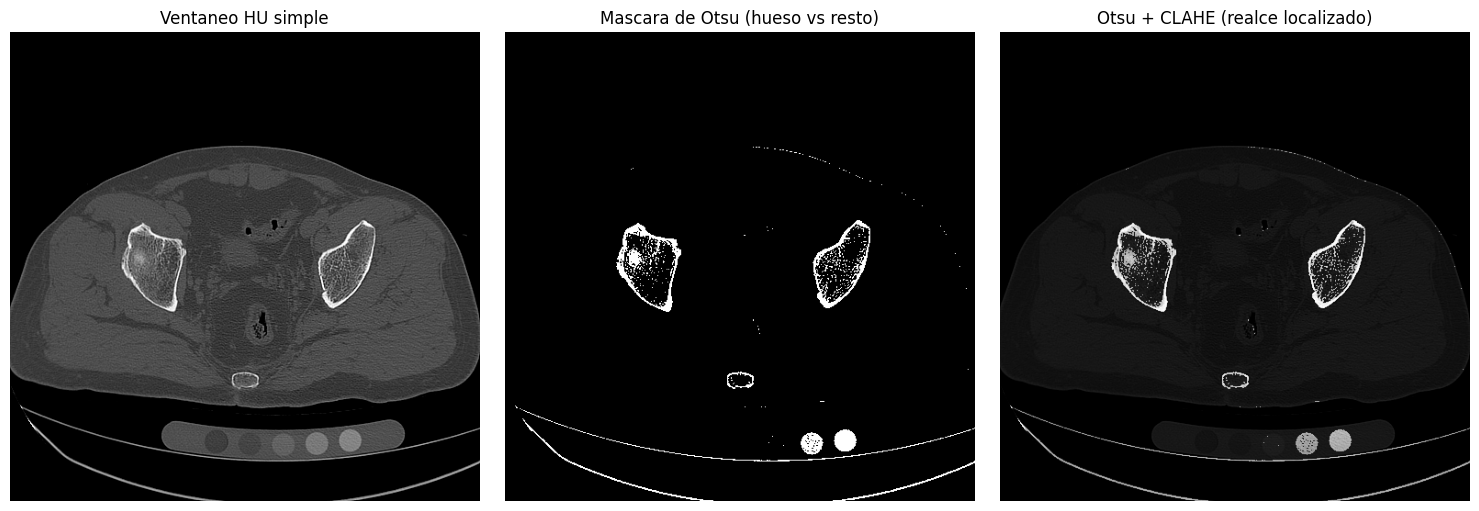

In [114]:
mid_slice_idx = volume.shape[0] // 2
imagen_simple = windowed[mid_slice_idx]
imagen_realzada = enhance_bone_contrast(imagen_simple)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(imagen_simple, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Ventaneo HU simple")
axes[1].imshow(imagen_simple > threshold_otsu(imagen_simple[imagen_simple > 0]), cmap="gray")
axes[1].set_title("Mascara de Otsu (hueso vs resto)")
axes[2].imshow(imagen_realzada, cmap="gray", vmin=0, vmax=1)
axes[2].set_title("Otsu + CLAHE (realce localizado)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

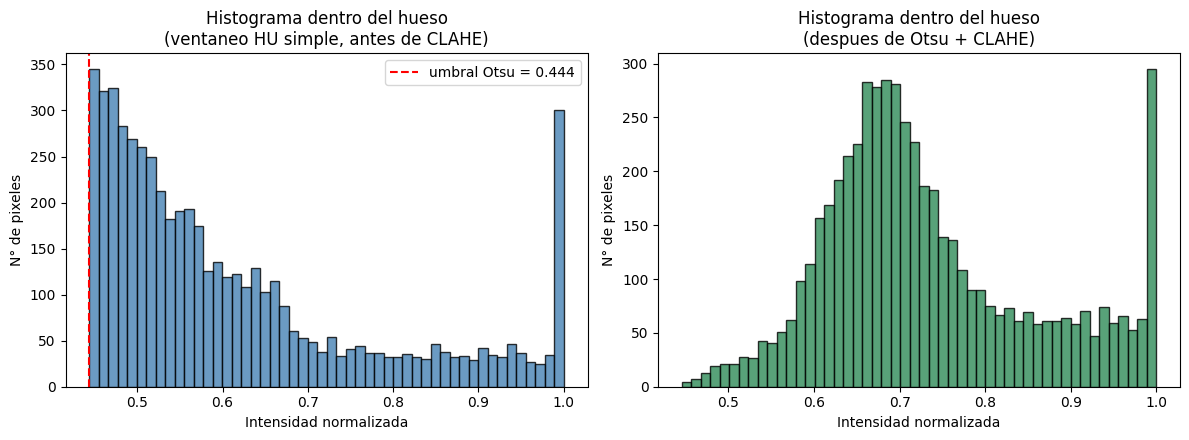

Antes  -> media=0.616, std=0.162, rango=(0.444, 1.000)
Despues -> media=0.734, std=0.125, rango=(0.446, 1.000)


In [115]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Histograma de la zona de hueso ANTES de CLAHE (solo ventaneo + Otsu como mascara)
otsu_thresh_hist = threshold_otsu(imagen_simple[imagen_simple > 0])
bone_mask_hist = imagen_simple > otsu_thresh_hist

valores_antes = imagen_simple[bone_mask_hist]
valores_despues = imagen_realzada[bone_mask_hist]

axes[0].hist(valores_antes, bins=50, color="steelblue", alpha=0.8, edgecolor="black")
axes[0].set_title("Histograma dentro del hueso\n(ventaneo HU simple, antes de CLAHE)")
axes[0].set_xlabel("Intensidad normalizada")
axes[0].set_ylabel("N° de pixeles")
axes[0].axvline(otsu_thresh_hist, color="red", linestyle="--", label=f"umbral Otsu = {otsu_thresh_hist:.3f}")
axes[0].legend()

axes[1].hist(valores_despues, bins=50, color="seagreen", alpha=0.8, edgecolor="black")
axes[1].set_title("Histograma dentro del hueso\n(despues de Otsu + CLAHE)")
axes[1].set_xlabel("Intensidad normalizada")
axes[1].set_ylabel("N° de pixeles")

plt.tight_layout()
plt.show()

print(f"Antes  -> media={valores_antes.mean():.3f}, std={valores_antes.std():.3f}, "
      f"rango=({valores_antes.min():.3f}, {valores_antes.max():.3f})")
print(f"Despues -> media={valores_despues.mean():.3f}, std={valores_despues.std():.3f}, "
      f"rango=({valores_despues.min():.3f}, {valores_despues.max():.3f})")

## 14. EDA de fragmentos por region anatomica

Se asigna cada label a una region anatomica aproximada: sacro, coxal izquierdo o coxal derecho. Luego se calcula el volumen fisico de cada fragmento usando el spacing en milimetros.

In [116]:
def label_to_region(label):
    if label == 0:
        return "background"
    if 1 <= label <= 10:
        return "sacro"
    if 11 <= label <= 20:
        return "coxal_izquierdo"
    if 21 <= label <= 30:
        return "coxal_derecho"
    return "desconocido"


fragment_rows = []

for _, row in df.iterrows():
    label_img = sitk.ReadImage(str(resolve_repo_path(row["label_path"])))
    label_vol = sitk.GetArrayFromImage(label_img)
    spacing = tuple(float(value) for value in label_img.GetSpacing())
    voxel_volume_mm3 = spacing[0] * spacing[1] * spacing[2]

    labels_present = np.unique(label_vol)
    labels_present = labels_present[labels_present != 0]

    for lab in labels_present:
        n_voxels = int(np.sum(label_vol == lab))
        fragment_rows.append({
            "case_id": row["case_id"],
            "label": int(lab),
            "region": label_to_region(int(lab)),
            "n_voxels": n_voxels,
            "volume_mm3": n_voxels * voxel_volume_mm3,
        })

frag_df = pd.DataFrame(fragment_rows)
frag_df.to_csv(GENERATED_DATA_DIR / "metadata_fragments.csv", index=False)
print(f"Total de fragmentos individuales en el dataset: {len(frag_df)}")
frag_df.head(10)

Total de fragmentos individuales en el dataset: 575


,case_id,label,region,n_voxels,volume_mm3
0,001,1,sacro,458539,223895.999430
1,001,11,coxal_izquierdo,762194,372165.044608
2,001,12,coxal_izquierdo,63957,31229.004372
3,001,21,coxal_derecho,844349,412279.791300
4,002,1,sacro,323928,176044.906041
5,002,2,sacro,39087,21242.582433
6,002,11,coxal_izquierdo,502549,273119.926299
7,002,21,coxal_derecho,470491,255697.389198
8,002,22,coxal_derecho,15260,8293.340700
9,002,23,coxal_derecho,19132,10397.653622


## 15. Resumen general del EDA

Se reporta el numero total de fragmentos y su distribucion por caso. Esto permite identificar si hay casos simples y casos mas complejos.

In [117]:
print("=== RESUMEN GENERAL ===")
print(f"Total de fragmentos (todas las regiones, todos los casos): {len(frag_df)}")
print(f"Fragmentos por caso -> min: {frag_df.groupby('case_id').size().min()}, "
      f"max: {frag_df.groupby('case_id').size().max()}, "
      f"media: {frag_df.groupby('case_id').size().mean():.2f}")

print("\n=== DISTRIBUCIÓN POR REGIÓN ANATÓMICA ===")
print(frag_df["region"].value_counts())

print("\n=== FRAGMENTOS POR REGIÓN, POR CASO (promedio) ===")
frag_por_region_caso = frag_df.groupby(["case_id", "region"]).size().reset_index(name="n_fragmentos")
print(frag_por_region_caso.groupby("region")["n_fragmentos"].describe())

=== RESUMEN GENERAL ===
Total de fragmentos (todas las regiones, todos los casos): 575
Fragmentos por caso -> min: 3, max: 9, media: 5.75

=== DISTRIBUCIÓN POR REGIÓN ANATÓMICA ===
region
coxal_izquierdo    215
coxal_derecho      207
sacro              153
Name: count, dtype: int64

=== FRAGMENTOS POR REGIÓN, POR CASO (promedio) ===
                 count  mean       std  min  25%  50%  75%  max
region                                                         
coxal_derecho    100.0  2.07  0.987344  1.0  1.0  2.0  3.0  4.0
coxal_izquierdo  100.0  2.15  1.067187  1.0  1.0  2.0  3.0  6.0
sacro            100.0  1.53  0.658357  1.0  1.0  1.0  2.0  4.0


## 16. Analisis de volumen de fragmentos

Se revisa la distribucion de volumenes en mm3. Los fragmentos muy pequenos pueden representar retos para segmentacion y metricas.

In [118]:
print("=== VOLUMEN DE FRAGMENTOS (mm³) ===")
print(frag_df["volume_mm3"].describe())

# Fragmentos sospechosamente pequeños (posible ruido de anotación vs. fragmento real)
umbral_pequeno = frag_df["volume_mm3"].quantile(0.05)  # percentil 5 más chico
pequenos = frag_df[frag_df["volume_mm3"] < umbral_pequeno]
print(f"\nFragmentos por debajo del percentil 5 de volumen (<{umbral_pequeno:.1f} mm³): {len(pequenos)}")
print(pequenos[["case_id", "region", "label", "volume_mm3"]].sort_values("volume_mm3").head(10))

=== VOLUMEN DE FRAGMENTOS (mm³) ===
count       575.000000
mean     135836.241955
std      114659.517155
min         282.212597
25%       23250.124644
50%      128182.935724
75%      234834.021490
max      416131.106541
Name: volume_mm3, dtype: float64

Fragmentos por debajo del percentil 5 de volumen (<3145.0 mm³): 29
    case_id           region  label   volume_mm3
299     052    coxal_derecho     23   282.212597
482     085            sacro      2   313.483475
215     038    coxal_derecho     23   518.747187
430     075  coxal_izquierdo     13   641.070251
329     057  coxal_izquierdo     13   683.141804
122     023  coxal_izquierdo     12   807.295788
478     084  coxal_izquierdo     14   812.787437
205     037            sacro      2   947.445813
477     084  coxal_izquierdo     13  1040.887642
312     054    coxal_derecho     24  1190.747253


## 17. Fragmento principal por hueso

Para cada caso y region, se identifica el fragmento de mayor volumen como fragmento principal. Los demas fragmentos se consideran conminutos para analisis posterior.

In [119]:
def get_main_fragment_per_bone(frag_df):
    rows = []
    for (case_id, region), group in frag_df.groupby(["case_id", "region"]):
        if region == "background":
            continue
        main_frag = group.loc[group["volume_mm3"].idxmax()]
        rows.append({
            "case_id": case_id,
            "region": region,
            "main_label": main_frag["label"],
            "main_volume_mm3": main_frag["volume_mm3"],
            "n_fragmentos_totales": len(group),
            "n_fragmentos_conminutos": len(group) - 1,
        })
    return pd.DataFrame(rows)

main_frag_df = get_main_fragment_per_bone(frag_df)
main_frag_df.to_csv(GENERATED_DATA_DIR / "main_fragments.csv", index=False)
main_frag_df.head(10)


,case_id,region,main_label,main_volume_mm3,n_fragmentos_totales,n_fragmentos_conminutos
0,001,coxal_derecho,21,412279.791300,1,0
1,001,coxal_izquierdo,11,372165.044608,2,1
2,001,sacro,1,223895.999430,1,0
3,002,coxal_derecho,21,255697.389198,3,2
4,002,coxal_izquierdo,11,273119.926299,1,0
5,002,sacro,1,176044.906041,2,1
6,003,coxal_derecho,21,281041.536819,1,0
7,003,coxal_izquierdo,11,236036.146324,4,3
8,003,sacro,1,181401.174675,1,0
9,004,coxal_derecho,21,214046.217773,2,1


## 18. Huesos fracturados y no fracturados por region

Se resume cuantos huesos tienen un solo fragmento y cuantos presentan multiples fragmentos por region anatomica.

In [120]:
print("=== HUESOS SIN FRACTURA (un solo fragmento) POR REGIÓN ===")
sin_fractura = main_frag_df[main_frag_df["n_fragmentos_totales"] == 1]
print(sin_fractura["region"].value_counts())

print("\n=== % de huesos fracturados por región ===")
total_por_region = main_frag_df["region"].value_counts()
fracturados_por_region = main_frag_df[main_frag_df["n_fragmentos_totales"] > 1]["region"].value_counts()
pct_fracturado = (fracturados_por_region / total_por_region * 100).round(1)
print(pct_fracturado)

=== HUESOS SIN FRACTURA (un solo fragmento) POR REGIÓN ===
region
sacro              55
coxal_derecho      36
coxal_izquierdo    34
Name: count, dtype: int64

=== % de huesos fracturados por región ===
region
coxal_derecho      64.0
coxal_izquierdo    66.0
sacro              45.0
Name: count, dtype: float64


## 19. Graficas exploratorias del EDA

Se generan graficas para visualizar fragmentos por caso, volumen por region y distribuciones generales del dataset.

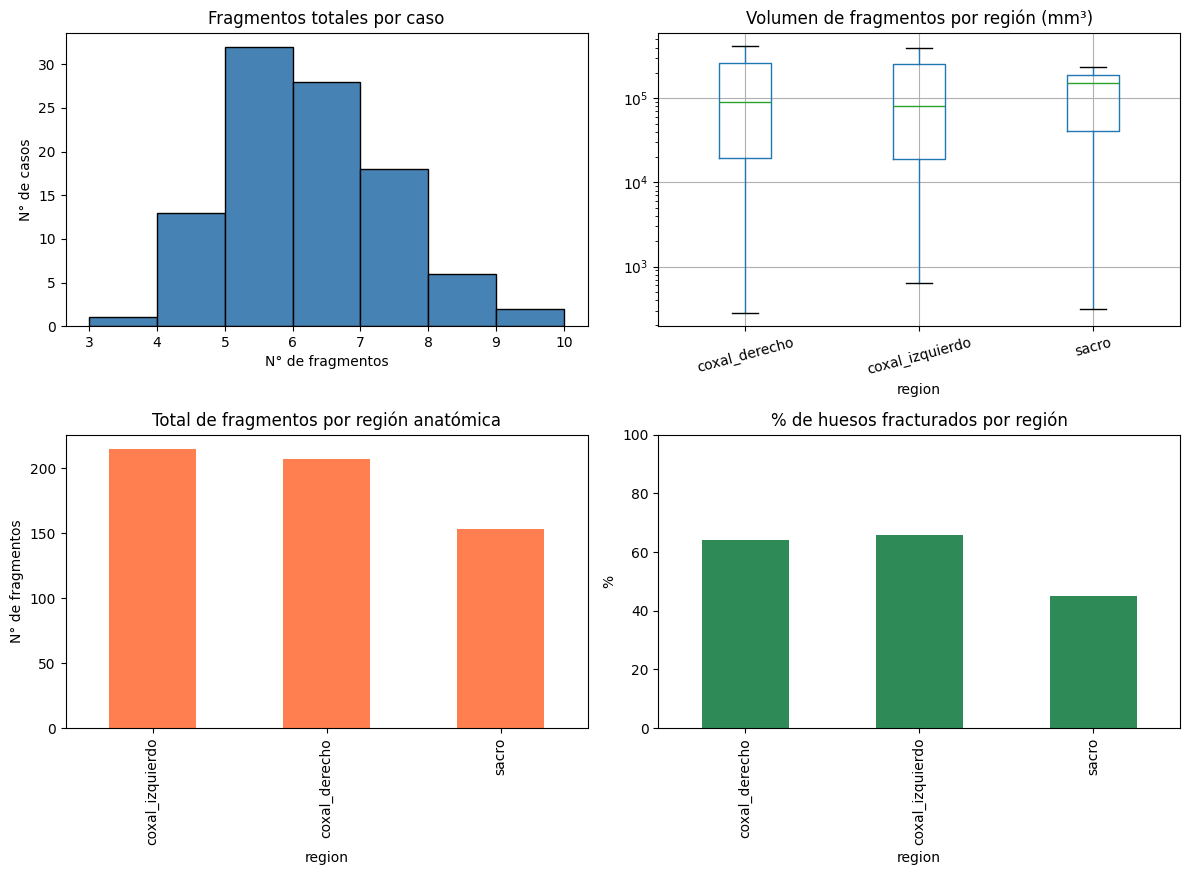

In [121]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Histograma: n° de fragmentos por caso (a nivel dataset completo)
frag_por_caso = frag_df.groupby("case_id").size()
axes[0, 0].hist(frag_por_caso, bins=range(frag_por_caso.min(), frag_por_caso.max() + 2), 
                 edgecolor="black", color="steelblue")
axes[0, 0].set_title("Fragmentos totales por caso")
axes[0, 0].set_xlabel("N° de fragmentos")
axes[0, 0].set_ylabel("N° de casos")

# Boxplot: volumen de fragmento por región
frag_df.boxplot(column="volume_mm3", by="region", ax=axes[0, 1])
axes[0, 1].set_title("Volumen de fragmentos por región (mm³)")
axes[0, 1].set_yscale("log")  # log porque probablemente hay outliers grandes
plt.sca(axes[0, 1])
plt.xticks(rotation=15)

# Barras: cantidad de fragmentos por región (total dataset)
frag_df["region"].value_counts().plot(kind="bar", ax=axes[1, 0], color="coral")
axes[1, 0].set_title("Total de fragmentos por región anatómica")
axes[1, 0].set_ylabel("N° de fragmentos")

# Barras: % de huesos fracturados por región
pct_fracturado.plot(kind="bar", ax=axes[1, 1], color="seagreen")
axes[1, 1].set_title("% de huesos fracturados por región")
axes[1, 1].set_ylabel("%")
axes[1, 1].set_ylim(0, 100)

plt.suptitle("")  # quita el título automático feo que pone pandas
plt.tight_layout()
plt.show()

## 20. Visualizacion volumetrica inicial

A partir de aqui se construye la evidencia visual del volumen crudo. Se incluyen MIP y una reconstruccion por malla dentro de este mismo notebook, siguiendo la recomendacion de pasar de puntos a superficies.

### 20.1 MIP raw

Se define una proyeccion de maxima intensidad usando un umbral HU para hueso. El MIP conserva, para cada direccion, los voxeles de mayor intensidad y permite una vista volumetrica inicial.

In [122]:
def compute_mip(volume, hu_threshold=300, axis=0):
    """Proyeccion de maxima intensidad sobre el volumen MHA (z, y, x).

    axis=0: axial; axis=1: coronal; axis=2: sagital.
    """
    bone_only = np.where(volume > hu_threshold, volume, 0)
    return np.max(bone_only, axis=axis)

### 20.2 MIP en tres vistas

Se generan vistas axial, coronal y sagital del caso 001. Esta evidencia complementa el visualizador 3D y ayuda a documentar el volumen crudo.

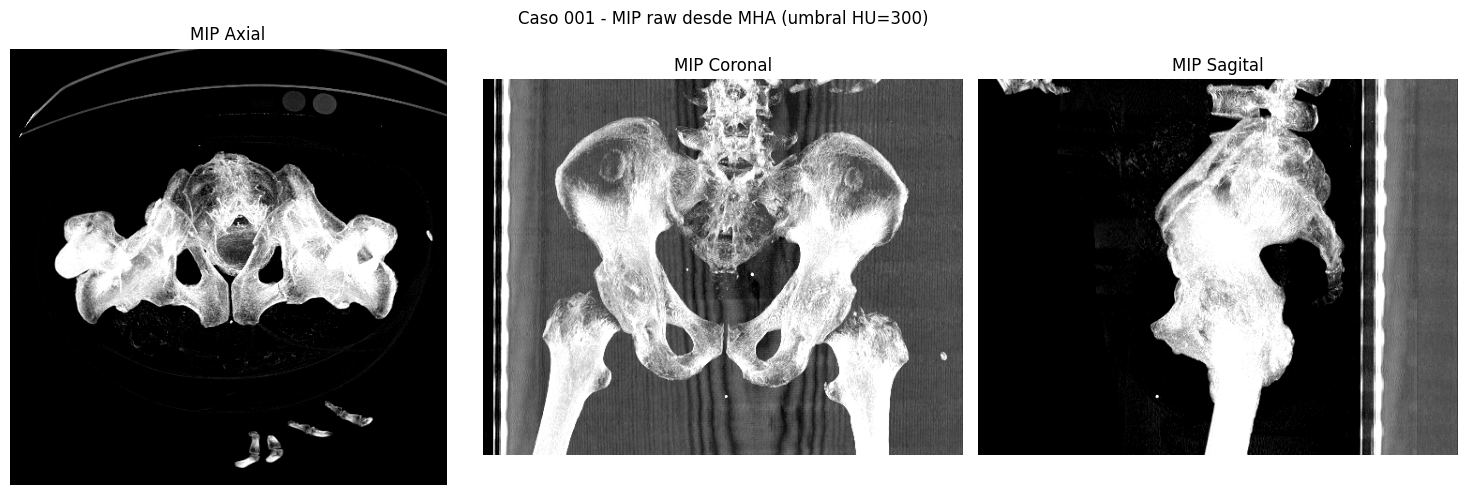

In [123]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# El volumen cargado con SimpleITK usa orden (z, y, x)
mip_axial = compute_mip(volume, hu_threshold=300, axis=0)
mip_coronal = compute_mip(volume, hu_threshold=300, axis=1)
mip_sagital = compute_mip(volume, hu_threshold=300, axis=2)

vmax_hueso = 1500

axes[0].imshow(mip_axial, cmap="gray", origin="lower", vmin=300, vmax=vmax_hueso)
axes[0].set_title("MIP Axial")
axes[0].axis("off")

axes[1].imshow(mip_coronal, cmap="gray", origin="lower", vmin=300, vmax=vmax_hueso)
axes[1].set_title("MIP Coronal")
axes[1].axis("off")

axes[2].imshow(mip_sagital, cmap="gray", origin="lower", vmin=300, vmax=vmax_hueso)
axes[2].set_title("MIP Sagital")
axes[2].axis("off")

plt.suptitle(f"Caso {case_id} - MIP raw desde MHA (umbral HU=300)")
plt.tight_layout()
plt.show()

### 20.3 Malla 3D interactiva

Se reconstruyen las superficies del sacro y los dos coxales mediante marching cubes. La malla permite rotar, desplazar y acercar el volumen, evitando la nube de puntos ruidosa del prototipo inicial. El HTML es una evidencia generada por este notebook.

In [124]:
import plotly.graph_objects as go
from skimage import measure

REGIONES_MALLA = {
    "sacro": {"labels": range(1, 11), "color": "#D9A62E"},
    "coxal_izquierdo": {"labels": range(11, 21), "color": "#2B8CBE"},
    "coxal_derecho": {"labels": range(21, 31), "color": "#E34A33"},
}


def crop_to_nonzero(mask, margin=8):
    coordinates = np.argwhere(mask)
    if len(coordinates) == 0:
        return None
    lower = np.maximum(coordinates.min(axis=0) - margin, 0)
    upper = np.minimum(coordinates.max(axis=0) + margin + 1, mask.shape)
    z0, y0, x0 = lower
    z1, y1, x1 = upper
    return mask[z0:z1, y0:y1, x0:x1], lower


def mesh_from_mask(mask, spacing_xyz, origin_zyx, stride=2):
    sampled = mask[::stride, ::stride, ::stride]
    spacing_zyx = (
        spacing_xyz[2] * stride,
        spacing_xyz[1] * stride,
        spacing_xyz[0] * stride,
    )
    vertices, faces, _, _ = measure.marching_cubes(
        sampled.astype(np.uint8), level=0.5, spacing=spacing_zyx
    )
    z = vertices[:, 0] + origin_zyx[0] * spacing_xyz[2]
    y = vertices[:, 1] + origin_zyx[1] * spacing_xyz[1]
    x = vertices[:, 2] + origin_zyx[2] * spacing_xyz[0]
    return x, y, z, faces


label_image = sitk.ReadImage(str(LABELS_DIR / "001.mha"))
label_volume = sitk.GetArrayFromImage(label_image)
spacing_xyz = label_image.GetSpacing()
mesh_traces = []

for region_name, config in REGIONES_MALLA.items():
    cropped = crop_to_nonzero(np.isin(label_volume, list(config["labels"])))
    if cropped is None:
        continue
    cropped_mask, origin_zyx = cropped
    x, y, z, faces = mesh_from_mask(cropped_mask, spacing_xyz, origin_zyx)
    mesh_traces.append(
        go.Mesh3d(
            x=x, y=y, z=z,
            i=faces[:, 2], j=faces[:, 1], k=faces[:, 0],
            color=config["color"], opacity=0.92,
            flatshading=False, name=region_name.replace("_", " "),
            lighting={"ambient": 0.42, "diffuse": 0.82, "roughness": 0.5},
        )
    )

mesh_figure = go.Figure(mesh_traces)
mesh_figure.update_layout(
    title="Caso 001 - malla 3D de sacro y coxales",
    scene={
        "xaxis_title": "x mm", "yaxis_title": "y mm", "zaxis_title": "z mm",
        "aspectmode": "data", "camera": {"eye": {"x": 1.45, "y": 1.4, "z": 0.85}},
    },
    legend={"orientation": "h", "y": 0.02},
    margin={"l": 0, "r": 0, "t": 50, "b": 0},
    dragmode="orbit",
)
mesh_output = EVIDENCE_DIR / "visualizador_mesh_caso_001.html"
mesh_figure.write_html(mesh_output, include_plotlyjs=True)
print("Visualizador guardado en:", to_repo_relative(mesh_output))
mesh_figure

Visualizador guardado en: evidencias/visualizador_mesh_caso_001.html


## 21. Datos y targets para deteccion

Las mascaras expertas `.mha` se convierten en targets 2D. Los IDs 1-10 representan el sacro, 11-20 el coxal izquierdo y 21-30 el coxal derecho. En cada corte se genera una sola bounding box por region anatomica, uniendo sus fragmentos; las instancias originales se conservan para la etapa posterior de segmentacion.

In [125]:
from PIL import Image
import matplotlib.patches as patches

CLASS_ID_TO_NAME = {1: "sacro", 2: "coxal_izquierdo", 3: "coxal_derecho"}
TARGET_COLORS = {1: "#D9A62E", 2: "#2B8CBE", 3: "#E34A33"}


def instance_to_semantic(label_slice):
    semantic = np.zeros(label_slice.shape, dtype=np.uint8)
    semantic[(label_slice >= 1) & (label_slice <= 10)] = 1
    semantic[(label_slice >= 11) & (label_slice <= 20)] = 2
    semantic[(label_slice >= 21) & (label_slice <= 30)] = 3
    return semantic


def boxes_from_semantic(semantic_mask, min_pixels=20):
    boxes, labels, areas = [], [], []
    for class_id in CLASS_ID_TO_NAME:
        ys, xs = np.nonzero(semantic_mask == class_id)
        if xs.size < min_pixels:
            continue
        x_min, x_max = int(xs.min()), int(xs.max()) + 1
        y_min, y_max = int(ys.min()), int(ys.max()) + 1
        boxes.append([x_min, y_min, x_max, y_max])
        labels.append(class_id)
        areas.append((x_max - x_min) * (y_max - y_min))
    return (
        np.asarray(boxes, dtype=np.float32).reshape(-1, 4),
        np.asarray(labels, dtype=np.int64),
        np.asarray(areas, dtype=np.float32),
    )


def letterbox_pair(image, label, output_size=256):
    height, width = image.shape
    scale = min(output_size / width, output_size / height)
    new_width = max(1, int(round(width * scale)))
    new_height = max(1, int(round(height * scale)))
    offset_x = (output_size - new_width) // 2
    offset_y = (output_size - new_height) // 2

    image_resized = np.asarray(
        Image.fromarray(image.astype(np.float32), mode="F").resize(
            (new_width, new_height), Image.Resampling.BILINEAR
        ), dtype=np.float32
    )
    label_resized = np.asarray(
        Image.fromarray(label.astype(np.int32), mode="I").resize(
            (new_width, new_height), Image.Resampling.NEAREST
        ), dtype=np.int16
    )

    image_out = np.zeros((output_size, output_size), dtype=np.float32)
    label_out = np.zeros((output_size, output_size), dtype=np.int16)
    image_out[offset_y:offset_y + new_height, offset_x:offset_x + new_width] = image_resized
    label_out[offset_y:offset_y + new_height, offset_x:offset_x + new_width] = label_resized
    return image_out, label_out, {"scale": scale, "offset_x": offset_x, "offset_y": offset_y}


def build_detection_target(label_slice, case_id, slice_index, min_pixels=20):
    semantic = instance_to_semantic(label_slice)
    boxes, labels, areas = boxes_from_semantic(semantic, min_pixels)
    instance_ids = np.unique(label_slice)
    instance_ids = instance_ids[instance_ids != 0].astype(np.int64)
    return {
        "case_id": case_id,
        "slice_index": int(slice_index),
        "boxes": boxes,
        "labels": labels,
        "areas": areas,
        "class_names": [CLASS_ID_TO_NAME[int(label)] for label in labels],
        "semantic_mask": semantic,
        "instance_mask": label_slice.astype(np.int16),
        "instance_ids": instance_ids,
    }

In [ ]:
# Indice de cortes positivos sin mezclar pacientes entre splits
split_by_case = dict(zip(split_dataset["case_id"], split_dataset["split"]))
manifest_rows = []

for _, row in df.iterrows():
    label_volume_case = sitk.GetArrayFromImage(
        sitk.ReadImage(str(resolve_repo_path(row["label_path"])))
    )
    for slice_index, label_slice in enumerate(label_volume_case):
        semantic = instance_to_semantic(label_slice)
        _, labels, _ = boxes_from_semantic(semantic, min_pixels=20)
        if not labels.size:
            continue
        instance_ids = np.unique(label_slice)
        instance_ids = instance_ids[instance_ids != 0]
        manifest_rows.append({
            "split": split_by_case[row["case_id"]],
            "case_id": row["case_id"],
            "slice_index": slice_index,
            "n_regions": len(labels),
            "regions": "|".join(CLASS_ID_TO_NAME[int(value)] for value in labels),
            "n_instances": len(instance_ids),
        })

slice_manifest = pd.DataFrame(manifest_rows)
targets_dir = EVIDENCE_DIR / "datos_targets"
targets_dir.mkdir(parents=True, exist_ok=True)
slice_manifest.to_csv(targets_dir / "manifest_cortes_positivos.csv", index=False)

print(slice_manifest.groupby("split").agg(
    casos=("case_id", "nunique"),
    cortes_positivos=("slice_index", "size"),
    promedio_regiones=("n_regions", "mean"),
).round(2))

case_sets = {
    split: set(group["case_id"])
    for split, group in slice_manifest.groupby("split")
}
assert not (case_sets["train"] & case_sets["val"])
assert not (case_sets["train"] & case_sets["test"])
assert not (case_sets["val"] & case_sets["test"])
print("Fuga de pacientes entre splits: 0")

/var/folders/8s/r8s1f24512j4g34swfpyjjjm0000gn/T/ipykernel_6519/2922264119.py:43: DeprecationWarning:

'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)

/var/folders/8s/r8s1f24512j4g34swfpyjjjm0000gn/T/ipykernel_6519/2922264119.py:48: DeprecationWarning:

'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)



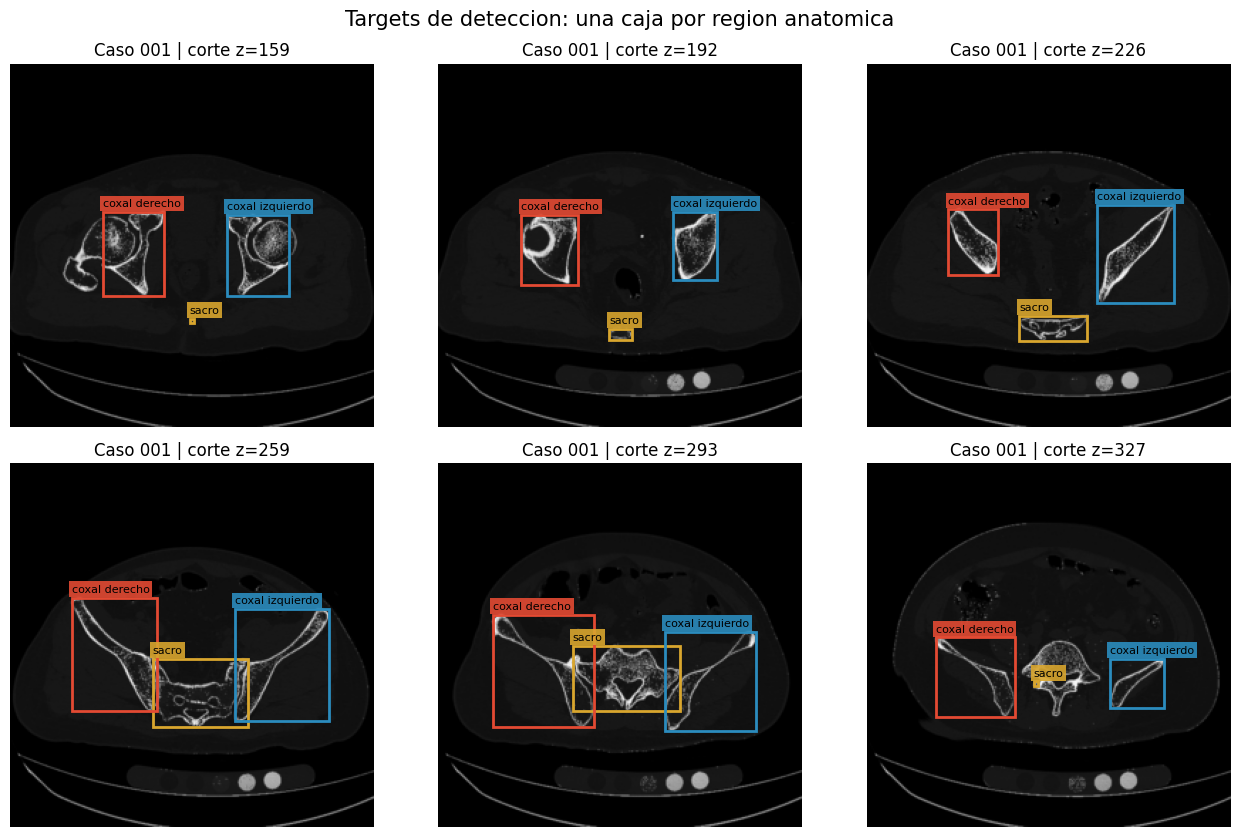

Evidencia guardada en: evidencias/datos_targets/targets_bounding_boxes_caso_001.png


In [ ]:
# Evidencia visual de las cajas generadas
case_id_targets = splits["train"].iloc[0]["case_id"]
case_row = df[df["case_id"] == case_id_targets].iloc[0]
image_targets = sitk.GetArrayFromImage(
    sitk.ReadImage(str(resolve_repo_path(case_row["image_path"])))
).astype(np.float32)
label_targets = sitk.GetArrayFromImage(
    sitk.ReadImage(str(resolve_repo_path(case_row["label_path"])))
).astype(np.int16)

case_manifest = slice_manifest[
    (slice_manifest["case_id"] == case_id_targets) & (slice_manifest["n_regions"] == 3)
]
positions = np.linspace(0, len(case_manifest) - 1, 6).astype(int)
preview_slices = case_manifest.iloc[positions]["slice_index"].astype(int).tolist()

fig, axes = plt.subplots(2, 3, figsize=(13, 8.5))
for axis, slice_index in zip(axes.ravel(), preview_slices):
    image = apply_hu_window(image_targets[slice_index])
    image = enhance_bone_contrast(image)
    image, label, transform = letterbox_pair(image, label_targets[slice_index], 256)
    scaled_min_pixels = max(1, int(round(20 * transform["scale"] ** 2)))
    target = build_detection_target(label, case_id_targets, slice_index, scaled_min_pixels)
    axis.imshow(image, cmap="gray", vmin=0, vmax=1)
    for box, class_id in zip(target["boxes"], target["labels"]):
        x_min, y_min, x_max, y_max = box
        color = TARGET_COLORS[int(class_id)]
        axis.add_patch(patches.Rectangle(
            (x_min, y_min), x_max - x_min, y_max - y_min,
            linewidth=2, edgecolor=color, facecolor="none"
        ))
        axis.text(
            x_min, max(8, y_min - 4),
            CLASS_ID_TO_NAME[int(class_id)].replace("_", " "),
            fontsize=8, color="black",
            bbox={"facecolor": color, "alpha": 0.9, "pad": 2, "edgecolor": "none"},
        )
    axis.set_title(f"Caso {case_id_targets} | corte z={slice_index}")
    axis.axis("off")

fig.suptitle("Targets de deteccion: una caja por region anatomica", fontsize=15)
fig.tight_layout()
targets_preview_path = targets_dir / f"targets_bounding_boxes_caso_{case_id_targets}.png"
fig.savefig(targets_preview_path, dpi=180, bbox_inches="tight")
plt.show()
print("Evidencia guardada en:", to_repo_relative(targets_preview_path))

### 21.1 Dataset para integracion con el modelo

El dataset devuelve la imagen con forma `(canales, 256, 256)` y un diccionario con cajas `xyxy`, clases, areas, mascaras e identificadores. Puede producir NumPy o tensores PyTorch y usa un `collate` para cantidades variables de cajas.

In [ ]:
from matplotlib.pylab import record


class PengwinDetectionDataset:
    def __init__(self, split="train", image_size=256, channels=1, as_torch=False):
        if split not in {"train", "val", "test"}:
            raise ValueError("split debe ser train, val o test")
        if channels not in {1, 3}:
            raise ValueError("channels debe ser 1 o 3")
        self.image_size = image_size
        self.channels = channels
        self.as_torch = as_torch
        self.records = slice_manifest[slice_manifest["split"] == split][
            ["case_id", "slice_index"]
        ].to_dict("records")
        self._cached_case_id = None

    def __len__(self):
        return len(self.records)

    def _load_case(self, case_id):
        if case_id != self._cached_case_id:
            row = df[df["case_id"] == case_id].iloc[0]
            image_itk = sitk.ReadImage(str(resolve_repo_path(row["image_path"])))
            label_itk = sitk.ReadImage(str(resolve_repo_path(row["label_path"])))
            self._image = sitk.GetArrayFromImage(image_itk).astype(np.float32)
            self._label = sitk.GetArrayFromImage(label_itk).astype(np.int16)
            self._spacing = tuple(float(value) for value in image_itk.GetSpacing())
            self._cached_case_id = case_id
        return self._image, self._label, self._spacing

    def __getitem__(self, index):
        record = self.records[index]
        image_volume, label_volume, spacing = self._load_case(record["case_id"])
        image = apply_hu_window(image_volume[record["slice_index"]])
        image = enhance_bone_contrast(image) 
        image, label, transform = letterbox_pair(
            image, label_volume[record["slice_index"]], self.image_size
        )
        min_pixels = max(1, int(round(20 * transform["scale"] ** 2)))
        target = build_detection_target(
            label, record["case_id"], record["slice_index"], min_pixels
        )
        target["spacing_xyz_mm"] = spacing
        target["transform"] = transform
        image = image[None, ...]
        if self.channels == 3:
            image = np.repeat(image, 3, axis=0)
        image = image.astype(np.float32)

        if not self.as_torch:
            return image, target

        import torch
        tensor_target = {
            **target,
            "boxes": torch.from_numpy(target["boxes"]),
            "labels": torch.from_numpy(target["labels"]),
            "areas": torch.from_numpy(target["areas"]),
            "semantic_mask": torch.from_numpy(target["semantic_mask"].astype(np.int64)),
            "instance_mask": torch.from_numpy(target["instance_mask"].astype(np.int64)),
            "image_id": torch.tensor([index], dtype=torch.int64),
        }
        return torch.from_numpy(image), tensor_target


def detection_collate(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)


train_detection_dataset = PengwinDetectionDataset(split="train", as_torch=False)
sample_image, sample_target = train_detection_dataset[0]
print("Cortes positivos de entrenamiento:", len(train_detection_dataset))
print("Forma de imagen:", sample_image.shape)
print("Forma de cajas:", sample_target["boxes"].shape)
print("Clases:", sample_target["class_names"])

Cortes positivos de entrenamiento: 18072
Forma de imagen: (1, 256, 256)
Forma de cajas: (1, 4)
Clases: ['coxal_izquierdo']


/var/folders/8s/r8s1f24512j4g34swfpyjjjm0000gn/T/ipykernel_6519/2922264119.py:43: DeprecationWarning:

'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)

/var/folders/8s/r8s1f24512j4g34swfpyjjjm0000gn/T/ipykernel_6519/2922264119.py:48: DeprecationWarning:

'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)



In [ ]:
# Regenerar batch_fijo.pt con el preprocesamiento actualizado (Otsu + CLAHE)
ds_fijo = PengwinDetectionDataset(split="train", as_torch=True)

# Mismos 6 casos "representativos" que ya usabas (o ajusta los indices si quieres otros)
idxs_fijos = np.linspace(0, len(ds_fijo) - 1, 6).astype(int)
muestras_fijas = [ds_fijo[int(i)] for i in idxs_fijos]

batch_fijo = {
    "imgs": torch.stack([s[0] for s in muestras_fijas]),
    "boxes": [s[1]["boxes"] for s in muestras_fijas],
    "labels": [s[1]["labels"] for s in muestras_fijas],
    "case_ids": [s[1]["case_id"] for s in muestras_fijas],
    "slice_index": [s[1]["slice_index"] for s in muestras_fijas],
}

batch_path = EVIDENCE_DIR / "batch_fijo.pt"
torch.save(batch_fijo, batch_path)
print(f"batch_fijo.pt regenerado en: {to_repo_relative(batch_path)}")
print(f"Imagenes: {batch_fijo['imgs'].shape} | dtype: {batch_fijo['imgs'].dtype}")
print(f"Rango de intensidades: ({batch_fijo['imgs'].min():.3f}, {batch_fijo['imgs'].max():.3f})")

/var/folders/8s/r8s1f24512j4g34swfpyjjjm0000gn/T/ipykernel_6519/2922264119.py:43: DeprecationWarning:

'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)

/var/folders/8s/r8s1f24512j4g34swfpyjjjm0000gn/T/ipykernel_6519/2922264119.py:48: DeprecationWarning:

'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)



batch_fijo.pt regenerado en: evidencias/batch_fijo.pt
Imagenes: torch.Size([6, 1, 256, 256]) | dtype: torch.float32
Rango de intensidades: (0.000, 0.998)


# 21. Definicion del Backbone
Definimos dos arquitecturas para el backbone, una siendo la base y otra con ciertos ajustes para realizar una mejor extracción de la información. Luego realizamos distintas pruebas para comprobar que efectivamente funciona mejor y que la salida obtenida es igual a la esperada.

In [ ]:
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NAMES = ["base", "plus"]
RESULTADOS = {n: {} for n in NAMES}   # se llena en las pruebas y se resume al final
print("torch", torch.__version__, "| dispositivo:", DEVICE)

torch 2.14.0 | dispositivo: cpu


In [ ]:
class FundidoraPC(nn.Module):
    """4 bloques Conv3x3 -> BatchNorm -> ReLU -> MaxPool2x2 (version base)."""

    def __init__(self, in_channels=3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(kernel_size=2)

        self.global_pool = nn.AdaptiveAvgPool2d(output_size=1)
        self.out_features = 256

    def _encode(self, x):
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool3(torch.relu(self.bn3(self.conv3(x))))
        # Solo 4 MaxPool en total: no agregar pooling extra.
        return self.pool4(torch.relu(self.bn4(self.conv4(x))))

    def forward(self, x):
        feature_map = self._encode(x)                                # [B, 256, H/16, W/16]
        pooled = self.global_pool(feature_map).flatten(start_dim=1)  # [B, 256]
        return pooled, feature_map



In [ ]:
class FundidoraPCPlus(FundidoraPC):
    """Base + bloque de contexto a stride 16 (convs dilatadas, residual)."""
    def __init__(self, in_channels=3, dilations=(2, 4)):
        super().__init__(in_channels)
        self.dilations = tuple(dilations)
        layers = []
        for d in self.dilations:
            layers += [nn.Conv2d(256, 256, kernel_size=3, padding=d, dilation=d, bias=False),
                       nn.BatchNorm2d(256), nn.ReLU(inplace=True)]
        self.context = nn.Sequential(*layers)

    def _encode(self, x):
        feature_map = super()._encode(x)
        return feature_map + self.context(feature_map)


def build_backbone(name="base", in_channels=1):
    if name == "base":
        return FundidoraPC(in_channels=in_channels)
    if name == "plus":
        return FundidoraPCPlus(in_channels=in_channels)
    raise ValueError(f"backbone desconocido: {name!r}")


BASE_LAYERS = [(3, 1, 1), (2, 2, 1)] * 4          # (kernel, stride, dilation)
PLUS_LAYERS = BASE_LAYERS + [(3, 1, 2), (3, 1, 4)]
LAYERS = {"base": BASE_LAYERS, "plus": PLUS_LAYERS}

def theoretical_receptive_field(layers):
    r, j = 1, 1
    for k, s, d in layers:
        r += (k - 1) * d * j
        j *= s
    return r, j

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


def make_models(train=False):
    out = {}
    for n in NAMES:
        torch.manual_seed(SEED)
        m = build_backbone(n, in_channels=1).to(DEVICE)
        out[n] = m.train() if train else m.eval()
    return out

MODELS = make_models()
for n, m in MODELS.items():
    RESULTADOS[n]["parametros"] = count_parameters(m)
    RESULTADOS[n]["rf_teorico"] = theoretical_receptive_field(LAYERS[n])[0]
    print(f"{n:5s} parametros = {count_parameters(m):>9,} | RF teorico = {RESULTADOS[n]['rf_teorico']} px")

base  parametros =   388,800 | RF teorico = 46 px
plus  parametros = 1,569,472 | RF teorico = 238 px


### Pruebas del backbone

In [ ]:
# Prueba 1 shapes
# Esperado: 256: 16, 224: 14, 192: 12

esperado_por_resolucion = {256: 16, 224: 14, 192: 12}

for name, m in MODELS.items():
    for size, hw in esperado_por_resolucion.items():
        for B in (1, 4):
            with torch.no_grad():
                pooled, fmap = m(torch.rand(B, 1, size, size, device=DEVICE))
            assert pooled.shape == (B, 256), (name, size, B, pooled.shape)
            assert fmap.shape == (B, 256, hw, hw), (name, size, B, fmap.shape)
    print(f"[{name}] shapes OK  (256->16x16, 224->14x14, 192->12x12)")

[base] shapes OK  (256->16x16, 224->14x14, 192->12x12)
[plus] shapes OK  (256->16x16, 224->14x14, 192->12x12)


In [ ]:
#Prueba 2 

x = torch.rand(4, 1, 256, 256, device=DEVICE)
for name, m in MODELS.items():
    with torch.no_grad():
        pooled, fmap = m(x)
    assert torch.isfinite(pooled).all() and torch.isfinite(fmap).all()
    assert fmap.min().item() >= 0, "el mapa deberia ser >= 0 (ReLU + MaxPool)"
    std_espacial = fmap.std(dim=(2, 3)).mean().item()
    muertos = int((fmap.amax(dim=(0, 2, 3)) == 0).sum().item())
    assert std_espacial > 0
    print(f"[{name}] min={fmap.min().item():.3f} max={fmap.max().item():.3f} "
          f"media={fmap.mean().item():.3f} | std espacial media={std_espacial:.4f} "
          f"| canales muertos={muertos}/256")
    RESULTADOS[name]["canales_muertos_init"] = muertos

[base] min=0.000 max=0.163 media=0.022 | std espacial media=0.0044 | canales muertos=36/256
[plus] min=0.000 max=0.163 media=0.024 | std espacial media=0.0052 | canales muertos=0/256


In [ ]:
#Prueba 3

class MiniDualHead(nn.Module):
    """Stand-in de DualHeadDetector: solo usa el primer elemento de la tupla."""
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        self.cls = nn.Linear(backbone.out_features, 3)
    def forward(self, x):
        pooled, _ = self.backbone(x)
        return self.cls(pooled)

for name, m in MODELS.items():
    with torch.no_grad():
        pooled, fmap = m(x)
        assert torch.allclose(pooled, fmap.mean(dim=(2, 3)), atol=1e-6)
        assert m.out_features == 256
        assert MiniDualHead(m).to(DEVICE)(x).shape == (4, 3)
    print(f"[{name}] pooled == mean(fmap), out_features=256, DualHead-compatible OK")

[base] pooled == mean(fmap), out_features=256, DualHead-compatible OK
[plus] pooled == mean(fmap), out_features=256, DualHead-compatible OK


In [ ]:
#Prueba 4 gradientes no nulos

for name, m in make_models(train=True).items():
    m.zero_grad()
    pooled, fmap = m(torch.rand(4, 1, 256, 256, device=DEVICE))
    (fmap.mean() + pooled.mean()).backward()
    normas = {}
    for n, p in m.named_parameters():
        assert p.grad is not None, f"sin gradiente: {n}"
        assert torch.isfinite(p.grad).all(), f"gradiente no finito: {n}"
        normas.setdefault(n.split(".")[0], []).append(p.grad.norm().item() ** 2)
    print(f"[{name}] norma de gradiente por bloque:")
    for k, v in normas.items():
        print(f"    {k:8s} {np.sqrt(sum(v)):.3e}")
    assert normas["conv1"][0] > 0

[base] norma de gradiente por bloque:
    conv1    4.333e-02
    bn1      5.895e-03
    conv2    1.838e-01
    bn2      6.662e-03
    conv3    2.086e-01
    bn3      7.601e-03
    conv4    2.391e-01
    bn4      1.734e-01
[plus] norma de gradiente por bloque:
    conv1    4.811e-02
    bn1      8.708e-03
    conv2    2.145e-01
    bn2      7.125e-03
    conv3    2.332e-01
    bn3      7.240e-03
    conv4    2.571e-01
    bn4      1.734e-01
    context  1.778e-01


[base] RF empirico = 46x46 px  (teorico 46)
[plus] RF empirico = 238x238 px  (teorico 238)


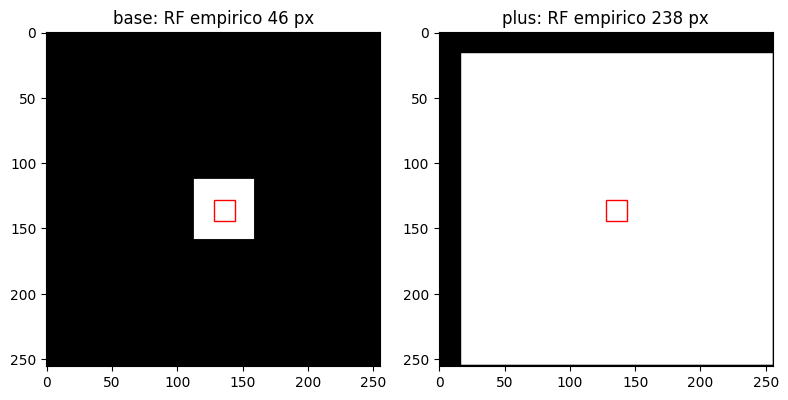

In [ ]:
#Prueba 5

def rf_empirico(model, size=256, cell=(8, 8)):
    model.eval()
    xin = torch.rand(1, 1, size, size, device=DEVICE, requires_grad=True)
    _, fmap = model(xin)
    fmap[0, :, cell[0], cell[1]].sum().backward()
    g = xin.grad[0, 0].abs() > 0
    ys = g.any(1).nonzero().flatten()
    xs = g.any(0).nonzero().flatten()
    return (ys.max() - ys.min() + 1).item(), (xs.max() - xs.min() + 1).item(), g.cpu()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (name, m) in zip(axes, make_models().items()):
    ext_y, ext_x, mascara = rf_empirico(m)
    teo = RESULTADOS[name]["rf_teorico"]
    assert ext_y <= teo and ext_x <= teo, (name, ext_y, ext_x, teo)
    RESULTADOS[name]["rf_empirico"] = max(ext_y, ext_x)
    print(f"[{name}] RF empirico = {ext_y}x{ext_x} px  (teorico {teo})")
    ax.imshow(mascara, cmap="gray"); ax.set_title(f"{name}: RF empirico {max(ext_y, ext_x)} px")
    ax.add_patch(Rectangle((8 * 16, 8 * 16), 16, 16, fill=False, ec="red"))  # celda (8,8)
plt.tight_layout(); plt.show()

centroide de cambio: fila 2.5, columna 10.5  (esperado ~ fila 3, columna 11)


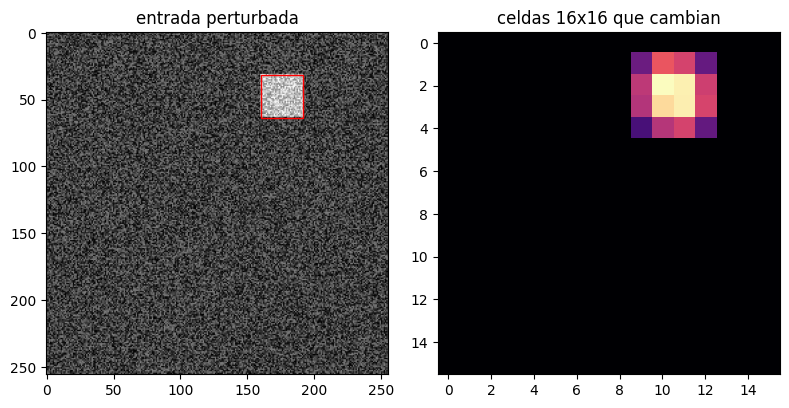

alineacion espacial OK


In [ ]:
#Prueba 6

m = make_models()["base"]
xin = torch.rand(1, 1, 256, 256, device=DEVICE)
y0, y1, x0, x1 = 32, 64, 160, 192
xp = xin.clone(); xp[..., y0:y1, x0:x1] += 1.0

with torch.no_grad():
    d = (m(xp)[1] - m(xin)[1]).abs().sum(1)[0]        # [16, 16]
cambiadas = d > 1e-6
assert cambiadas.any(), "la perturbacion no modifico ninguna celda"

# celdas que pueden verse afectadas: ventana de +-23 px (RF 46) alrededor del centro de cada celda
centros = torch.arange(16, device=DEVICE) * 16 + 7.5
def toca(c, a, b, half=23 + 2):
    return (c + half >= a) & (c - half <= b - 1)
esperada = toca(centros, y0, y1)[:, None] & toca(centros, x0, x1)[None, :]
fuera = int((cambiadas & ~esperada).sum().item())
assert fuera == 0, f"{fuera} celdas cambiaron fuera de la region esperada (ejes/offset mal)"

idx = torch.arange(16, device=DEVICE, dtype=torch.float32)
cy = ((d.sum(1) * idx).sum() / d.sum()).item()
cx = ((d.sum(0) * idx).sum() / d.sum()).item()
print(f"centroide de cambio: fila {cy:.1f}, columna {cx:.1f}  (esperado ~ fila 3, columna 11)")
assert abs(cy - 3) + abs(cx - 11) < abs(cy - 11) + abs(cx - 3), "posible transposicion de ejes x/y"

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(xp[0, 0].cpu(), cmap="gray"); ax[0].set_title("entrada perturbada")
ax[0].add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec="red"))
ax[1].imshow(d.cpu(), cmap="magma"); ax[1].set_title("celdas 16x16 que cambian")
plt.tight_layout(); plt.show()
print("alineacion espacial OK")

In [ ]:
#Prueba 7 
#Importante para CBAM y cabeza de detección

head = nn.Conv2d(256, 1 + 4 + 3, kernel_size=1).to(DEVICE)
for name, m in MODELS.items():
    with torch.no_grad():
        _, fmap = m(torch.rand(4, 1, 256, 256, device=DEVICE))
        salida = head(fmap)
    assert salida.shape == (4, 8, 16, 16), salida.shape
    print(f"[{name}] fmap {tuple(fmap.shape)} -> salida de cabeza {tuple(salida.shape)} OK")

[base] fmap (4, 256, 16, 16) -> salida de cabeza (4, 8, 16, 16) OK
[plus] fmap (4, 256, 16, 16) -> salida de cabeza (4, 8, 16, 16) OK


/var/folders/8s/r8s1f24512j4g34swfpyjjjm0000gn/T/ipykernel_6519/2922264119.py:43: DeprecationWarning:

'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)

/var/folders/8s/r8s1f24512j4g34swfpyjjjm0000gn/T/ipykernel_6519/2922264119.py:48: DeprecationWarning:

'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)



batch real: (6, 1, 256, 256) | casos: ['001', '021', '046', '063', '083', '100']
entrada: min=0.000 max=0.998
[base] correlacion mapa vs imagen reducida 16x16: +0.48, +0.73, +0.71, +0.67, +0.66, +0.50
[plus] correlacion mapa vs imagen reducida 16x16: +0.55, +0.77, +0.76, +0.71, +0.72, +0.58


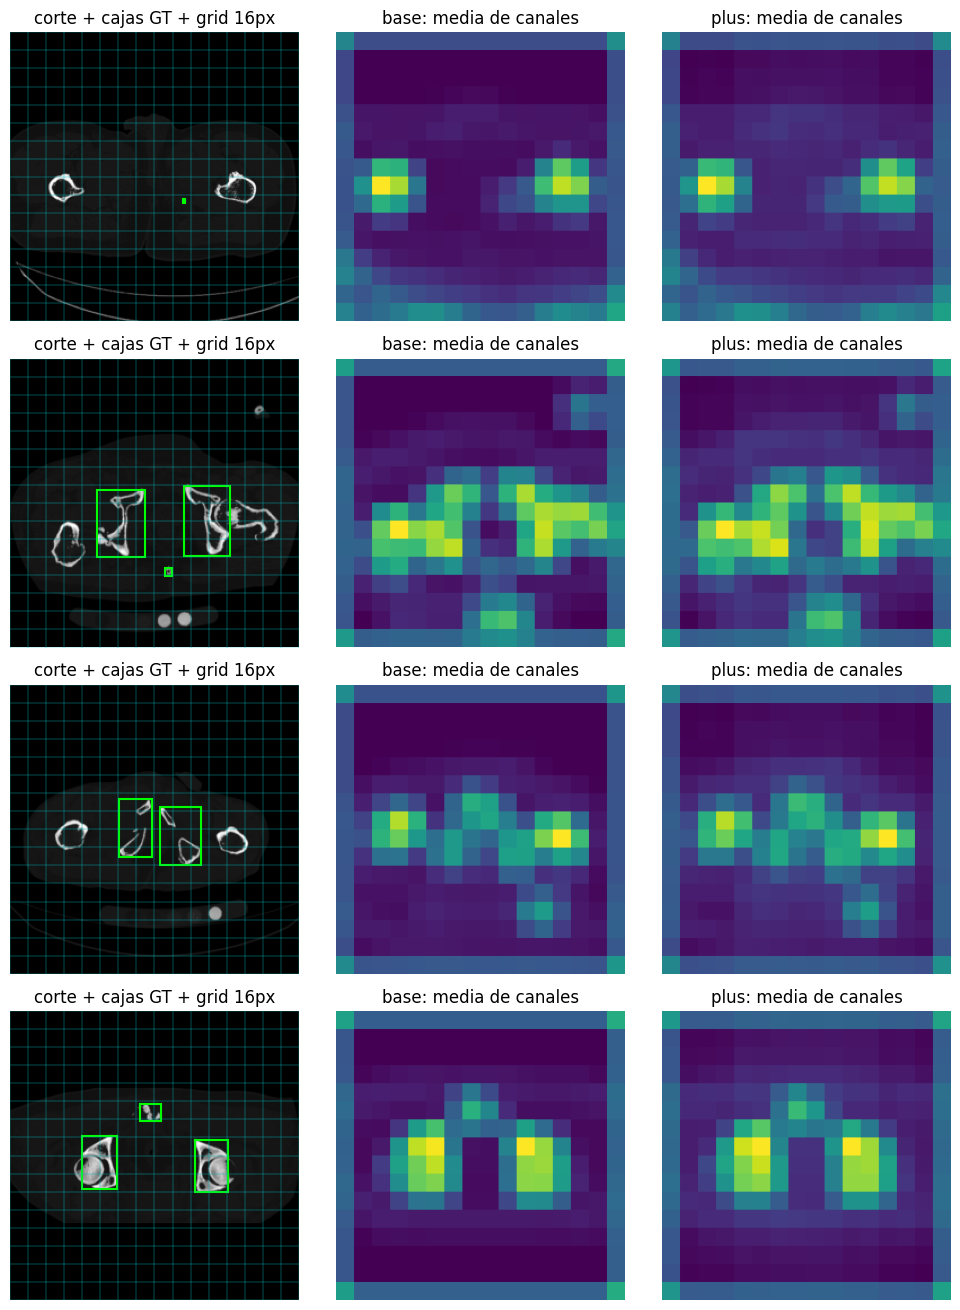

In [ ]:
#Prueba 8
#Batch real

if "PengwinDetectionDataset" in globals():
    ds = PengwinDetectionDataset(split="train", image_size=256, channels=1, as_torch=True)
    idxs = np.linspace(0, len(ds) - 1, 6).astype(int)
    muestras = [ds[int(i)] for i in idxs]
    imgs = torch.stack([s[0] for s in muestras]).to(DEVICE)
    targets = [s[1] for s in muestras]
    print("batch real:", tuple(imgs.shape), "| casos:", [t["case_id"] for t in targets])
else:
    print("PengwinDetectionDataset no esta definido: usando batch sintetico")
    imgs, targets = torch.rand(6, 1, 256, 256, device=DEVICE), [None] * 6

assert imgs.shape == (6, 1, 256, 256) and imgs.dtype == torch.float32
assert torch.isfinite(imgs).all() and imgs.min() >= 0 and imgs.max() <= 1, "entrada fuera de [0,1]"
print(f"entrada: min={imgs.min().item():.3f} max={imgs.max().item():.3f}")

mapas = {}
for name, m in MODELS.items():
    with torch.no_grad():
        pooled, fmap = m(imgs)
    assert fmap.shape == (6, 256, 16, 16) and torch.isfinite(fmap).all()
    mapas[name] = fmap.mean(1)                                   # [6, 16, 16]
    ref = F.adaptive_avg_pool2d(imgs, 16)[:, 0]
    corr = [torch.corrcoef(torch.stack([mapas[name][k].flatten(), ref[k].flatten()]))[0, 1].item()
            for k in range(6)]
    print(f"[{name}] correlacion mapa vs imagen reducida 16x16: "
          + ", ".join(f"{c:+.2f}" for c in corr))

n_ver = 4
fig, axes = plt.subplots(n_ver, 3, figsize=(10, 3.3 * n_ver))
for k in range(n_ver):
    img = imgs[k, 0].cpu()
    axes[k, 0].imshow(img, cmap="gray")
    for g in range(0, 257, 16):
        axes[k, 0].axhline(g - 0.5, lw=0.3, c="c"); axes[k, 0].axvline(g - 0.5, lw=0.3, c="c")
    if targets[k] is not None:
        for b in targets[k]["boxes"].numpy():
            axes[k, 0].add_patch(Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], fill=False, ec="lime", lw=1.5))
    axes[k, 0].set_title("corte + cajas GT + grid 16px")
    for j, name in enumerate(NAMES, start=1):
        up = F.interpolate(mapas[name][k][None, None].float(), size=256, mode="nearest")[0, 0].cpu()
        axes[k, j].imshow(up, cmap="viridis"); axes[k, j].set_title(f"{name}: media de canales")
    for a in axes[k]: a.axis("off")
plt.tight_layout(); plt.show()

In [ ]:
#Prueba 9

for name in NAMES:
    torch.manual_seed(SEED)
    m = build_backbone(name, 1).to(DEVICE)
    xb = imgs[:4]
    m.train()
    with torch.no_grad():
        _, f_train = m(xb)
    m.eval()
    with torch.no_grad():
        _, f_eval = m(xb)
    rel = ((f_train - f_eval).abs().mean() / f_train.abs().mean()).item()
    print(f"[{name}] diferencia relativa train vs eval: {rel:.1%}")
print("Si el loss baja en train pero el IoU en eval no, revisar esto antes de culpar a la cabeza o a los targets.")

[base] diferencia relativa train vs eval: 98.6%
[plus] diferencia relativa train vs eval: 98.5%
Si el loss baja en train pero el IoU en eval no, revisar esto antes de culpar a la cabeza o a los targets.


In [ ]:
#Prueba 10

def tiempo_forward_ms(model, B=8, n=10):
    xb = torch.rand(B, 1, 256, 256, device=DEVICE)
    model.eval()
    with torch.no_grad():
        for _ in range(3):
            model(xb)
        if DEVICE.type == "cuda": torch.cuda.synchronize()
        t = time.perf_counter()
        for _ in range(n):
            model(xb)
        if DEVICE.type == "cuda": torch.cuda.synchronize()
    return (time.perf_counter() - t) / n * 1000

for name, m in MODELS.items():
    RESULTADOS[name]["ms_forward_B8"] = round(tiempo_forward_ms(m), 1)

try:
    import pandas as pd
    print(pd.DataFrame(RESULTADOS).T.to_string())
except ImportError:
    for k, v in RESULTADOS.items(): print(k, v)

      parametros  rf_teorico  canales_muertos_init  rf_empirico  ms_forward_B8
base    388800.0        46.0                  36.0         46.0           62.6
plus   1569472.0       238.0                   0.0        238.0           77.0


## 22. Distancia de separación entre fragmentos

Esta sección calcula primero la distancia de referencia usando las máscaras MHA originales, que conservan los IDs de instancia. El fragmento principal de cada región se define como el de mayor volumen, igual que en el EDA. Se usa el espaciado físico del MHA en milímetros y `distance_transform_edt`.

Cada vóxel se interpreta como una celda física con el tamaño indicado por el header MHA. La máscara principal se dilata una celda en los tres ejes y sobre esa representación se calcula el EDT con el spacing anisotrópico. Así se mide la distancia borde a borde entre las celdas voxelizadas: si se tocan por cara, arista o esquina, la distancia es 0 mm. La medida corresponde a las máscaras discretas, no a una superficie anatómica continua. La comparación con predicciones se añadirá cuando el equipo produzca máscaras 3D de instancia.

La tabla final se guarda en `evidencias/distancias_referencia.csv`, con una fila por fragmento y caso. Las pruebas sintéticas de contacto y spacing se ejecutan desde la terminal con `python3 -m unittest discover -s tests -v`.


In [ ]:
from distancias_fragmentos import measure_fragment_separations

DISTANCE_CASES = df  # usa df.head(1) para una prueba rápida antes del dataset completo
distance_tables = []
for row in DISTANCE_CASES.itertuples(index=False):
    label_path = resolve_repo_path(row.label_path)
    label_image = sitk.ReadImage(str(label_path))
    instance_volume = sitk.GetArrayFromImage(label_image).astype(np.int16)
    case_distances = measure_fragment_separations(
        instance_volume,
        label_image.GetSpacing(),  # SimpleITK: (x, y, z) mm
        case_id=str(row.case_id),
    )
    distance_tables.append(case_distances)

distancias_referencia_df = pd.concat(distance_tables, ignore_index=True)
distance_table_path = EVIDENCE_DIR / "distancias_referencia.csv"
distancias_referencia_df.to_csv(distance_table_path, index=False)

print("Casos procesados:", distancias_referencia_df["case_id"].nunique())
print("Fragmentos con distancia:", len(distancias_referencia_df))
print("Fragmentos conminutos:", int((~distancias_referencia_df["is_main"]).sum()))
print("Archivo:", to_repo_relative(distance_table_path))
display(distancias_referencia_df.head(12))


Casos procesados: 100
Fragmentos con distancia: 575
Fragmentos conminutos: 275
Archivo: evidencias/distancias_referencia.csv


,case_id,region,fragment_id,main_fragment_id,is_main,n_voxels,distance_mm
0,001,coxal_derecho,21,21,True,844349,0.00000
1,001,coxal_izquierdo,11,11,True,762194,0.00000
2,001,coxal_izquierdo,12,11,False,63957,0.78125
3,001,sacro,1,1,True,458539,0.00000
4,002,coxal_derecho,21,21,True,470491,0.00000
5,002,coxal_derecho,22,21,False,15260,0.80000
6,002,coxal_derecho,23,21,False,19132,0.80000
7,002,coxal_izquierdo,11,11,True,502549,0.00000
8,002,sacro,1,1,True,323928,0.00000
9,002,sacro,2,1,False,39087,0.80000


### Interpretación del conteo y de las distancias

Se procesaron **100 casos** y la tabla contiene **575 filas**, una por cada fragmento identificado en las máscaras MHA. De estas filas, **300 corresponden a fragmentos principales** (uno por cada hueso/región presente en cada caso) y **275 a fragmentos conminutos**, es decir, fragmentos adicionales del mismo hueso. Así, “Fragmentos con distancia: 575” es el total de instancias registradas; “Fragmentos conminutos: 275” cuenta solo las instancias cuya separación respecto al fragmento principal se analiza.

El fragmento principal aparece con `distance_mm = 0` por definición: es la referencia y no se mide contra sí mismo. Las distancias pequeñas pueden ocurrir cuando los fragmentos están muy próximos, mientras que valores grandes también pueden ser válidos si están más separados.

Para interpretar cualquier valor, se debe comprobar que ambos fragmentos estén correctamente asociados al mismo hueso y que el cálculo use el espaciado físico correcto del MHA. Una distancia grande no es automáticamente un error, pero sí conviene revisar visualmente los casos extremos y verificar la máscara y la pertenencia anatómica.

La medición se calcula en 3D sobre máscaras voxelizadas, interpretando cada vóxel como una celda física; no es una distancia entre superficies anatómicas continuas o mallas. Las capturas son proyecciones 2D para inspección visual, por lo que no representan por sí solas la distancia 3D.

### 22.1. Revisión de la tabla de distancias

Se resumen las distancias de los fragmentos conminutos y se inspeccionan los valores más grandes. También se comprueba que el fragmento principal seleccionado por el cálculo coincida con el EDA previo. Los valores extremos deben revisarse sobre la imagen y la máscara antes de interpretarlos.


In [ ]:
conminuted_distances_df = distancias_referencia_df[~distancias_referencia_df["is_main"]].copy()
print("Resumen de distancia a fragmento principal (mm):")
display(conminuted_distances_df["distance_mm"].describe().to_frame().T)
print("Resumen por región anatómica (mm):")
display(conminuted_distances_df.groupby("region")["distance_mm"].agg(["count", "median", "max"]))
print("Mayores distancias: revisar estos casos visualmente")
display(conminuted_distances_df.nlargest(10, "distance_mm")[
    ["case_id", "region", "fragment_id", "main_fragment_id", "distance_mm"]
])

principal_check = (
    distancias_referencia_df[distancias_referencia_df["is_main"]]
    .merge(
        main_frag_df[["case_id", "region", "main_label"]],
        left_on=["case_id", "region", "fragment_id"],
        right_on=["case_id", "region", "main_label"],
        how="outer",
        indicator=True,
    )
)
assert (principal_check["_merge"] == "both").all()
print("Fragmentos principales coinciden con el EDA:", len(principal_check), "/", len(main_frag_df))


Resumen de distancia a fragmento principal (mm):


,count,mean,std,min,25%,50%,75%,max
distance_mm,275.0,2.124087,6.599212,0.625,0.78125,0.79895,0.824219,73.118287


Resumen por región anatómica (mm):


,count,median,max
region,,,
coxal_derecho,107,0.798950,73.118287
coxal_izquierdo,115,0.783203,50.820687
sacro,53,0.800000,11.515205


Mayores distancias: revisar estos casos visualmente


,case_id,region,fragment_id,main_fragment_id,distance_mm
547,096,coxal_derecho,23,21,73.118287
484,085,coxal_izquierdo,12,11,50.820687
309,054,coxal_derecho,24,21,40.368669
218,039,coxal_derecho,23,21,35.123064
24,005,coxal_derecho,23,21,24.291985
130,024,coxal_izquierdo,13,11,20.066722
565,099,coxal_izquierdo,12,11,14.226777
308,054,coxal_derecho,23,21,13.595506
478,084,coxal_izquierdo,14,11,12.930488
209,037,sacro,2,1,11.515205


Fragmentos principales coinciden con el EDA: 300 / 300


## 23. Segmentación de instancias: decoder semántico, centros y offsets

Esta sección implementa una propuesta propia para separar fragmentos: el decoder predice la región anatómica de cada píxel, centros de fragmento por región y vectores (offsets) desde los píxeles óseos hacia el centro de su instancia. Un postprocesamiento combina esas señales y devuelve IDs por fragmento.

### ¿Por qué elegimos centros + offsets?

La máscara semántica identifica sacro, coxal izquierdo y coxal derecho, pero por sí sola asignaría la misma etiqueta a todos los fragmentos de una región y no conservaría su identidad individual. La consigna del avance requiere separar cada fragmento, incluso cuando hay varios de la misma región. Por eso añadimos centros y offsets: cada centro propone una instancia y los píxeles óseos votan hacia el centro de su propio fragmento. Así podemos manejar un número variable de instancias sin reservar un canal fijo para cada ID, que cambia entre cortes y pacientes.

También se consideraron componentes conectados y bordes. Los componentes conectados pueden fusionar fragmentos que se tocan; una señal de borde es otra alternativa válida, pero requiere decidir cómo cerrar contornos incompletos. Centros + offsets ofrece una señal explícita de agrupación y un postprocesamiento determinista para reconstruir IDs. Es una decisión de diseño del equipo, no una arquitectura exigida literalmente por Ferro; se debe verificar con fragmentos pequeños y en contacto, usando `val`.

Las máscaras objetivo provienen de los MHA reales y de los splits fijos. Esta es una implementación inicial; no sustituye la integración ni el entrenamiento multitarea completo, y sus parámetros deben seleccionarse con validación, nunca con test.

### 23.1 Crear objetivos de centros y offsets desde las máscaras reales

Para cada píxel se conserva su clase anatómica y su ID de instancia. El centroide de cada ID genera un mapa de centros gaussiano; los offsets indican cuánto debe desplazarse cada píxel para llegar a ese centro. Se usa el ID original solo para crear la supervisión, no como una clase fija que el modelo deba memorizar entre pacientes.

In [ ]:
def build_instance_segmentation_targets(instance_mask, sigma=3.0):
    instance_mask = np.asarray(instance_mask, dtype=np.int32)
    if instance_mask.ndim != 2:
        raise ValueError(f"Se esperaba máscara 2D (y, x), se recibió {instance_mask.shape}")
    if sigma <= 0:
        raise ValueError("sigma debe ser positivo")

    height, width = instance_mask.shape
    semantic = instance_to_semantic(instance_mask).astype(np.int64)
    center_heatmaps = np.zeros((3, height, width), dtype=np.float32)
    offsets = np.zeros((2, height, width), dtype=np.float32)
    foreground = instance_mask > 0
    yy, xx = np.ogrid[:height, :width]
    radius = int(np.ceil(3 * sigma))

    for instance_id in np.unique(instance_mask[foreground]):
        instance_id = int(instance_id)
        if 1 <= instance_id <= 10:
            class_id = 1
        elif 11 <= instance_id <= 20:
            class_id = 2
        elif 21 <= instance_id <= 30:
            class_id = 3
        else:
            raise ValueError(f"ID de fragmento fuera de 1..30: {instance_id}")

        ys, xs = np.nonzero(instance_mask == instance_id)
        center_y, center_x = float(ys.mean()), float(xs.mean())
        y0, y1 = max(0, int(center_y) - radius), min(height, int(center_y) + radius + 1)
        x0, x1 = max(0, int(center_x) - radius), min(width, int(center_x) + radius + 1)
        gy, gx = np.mgrid[y0:y1, x0:x1]
        gaussian = np.exp(-((gy - center_y) ** 2 + (gx - center_x) ** 2) / (2 * sigma**2))
        gaussian /= max(float(gaussian.max()), 1e-8)
        center_heatmaps[class_id - 1, y0:y1, x0:x1] = np.maximum(
            center_heatmaps[class_id - 1, y0:y1, x0:x1], gaussian
        )
        offsets[0, ys, xs] = (center_x - xs) / width
        offsets[1, ys, xs] = (center_y - ys) / height

    return {
        "semantic": semantic,
        "centers": center_heatmaps,
        "offsets": offsets,
        "foreground": foreground,
        "instance_ids": np.unique(instance_mask[foreground]).astype(np.int32),
    }


### 23.2 Decoder de segmentación sobre el mapa compartido

El decoder recibe el mapa espacial `[B, 256, 16, 16]` del backbone/atención y lo aumenta progresivamente hasta la resolución de la máscara `[B, *, 256, 256]`. Además recibe priors espaciales de las cajas por región: se construyen con cajas reales durante entrenamiento y con cajas predichas después de NMS durante inferencia. Devuelve logits semánticos (4 canales), centros (3 canales, uno por región) y offsets `(x, y)`. Las ramas comparten las características decodificadas. El helper acepta el mismo contrato `{boxes, labels}` para cualquiera de las dos fuentes; no usa cajas reales durante inferencia. Como las cajas anotadas son más precisas que las predichas, al integrar conviene evaluar jitter de cajas o una transición gradual a cajas predichas durante el entrenamiento; la prueba con cajas reales solo verifica formas y gradientes, no elimina esa diferencia. Se usa interpolación bilineal seguida de convoluciones, en vez de convoluciones transpuestas, para evitar la configuración de kernel/stride que las guías advierten que puede causar artefactos de cuadrícula.

**Limitación a revisar:** este prototipo recibe solo el mapa final de 16 × 16 y todavía no incorpora conexiones de salto (skip connections). Las guías de clase las recomiendan para recuperar bordes y detalles finos desde niveles tempranos del encoder. Primero mediremos el comportamiento en fragmentos pequeños; si se pierden contornos, habrá que integrar mapas intermedios del backbone con Annie y Miguel, alineando los canales antes de concatenarlos. No se modifica aquí el backbone compartido.

In [ ]:
def build_detection_region_priors(detections, output_size=(256, 256), device=None):
    """Rasteriza cajas xyxy/clases 1..3 como tres priors espaciales por imagen."""
    height, width = map(int, output_size)
    if height <= 0 or width <= 0:
        raise ValueError("output_size debe tener dimensiones positivas")
    if isinstance(detections, dict):
        detections = [detections]

    priors = torch.zeros((len(detections), 3, height, width), dtype=torch.float32, device=device)
    for batch_index, detection in enumerate(detections):
        boxes = torch.as_tensor(detection["boxes"]).detach().to(device="cpu", dtype=torch.float32).numpy()
        labels = torch.as_tensor(detection["labels"]).detach().to(device="cpu", dtype=torch.int64).numpy()
        boxes = boxes.reshape(-1, 4)
        labels = labels.reshape(-1)
        if len(boxes) != len(labels):
            raise ValueError("Debe existir una clase por cada caja")
        for box, class_id in zip(boxes, labels):
            class_id = int(class_id)
            if class_id not in (1, 2, 3):
                raise ValueError(f"Clase anatómica fuera de 1..3: {class_id}")
            x0 = int(np.clip(np.floor(box[0]), 0, width))
            y0 = int(np.clip(np.floor(box[1]), 0, height))
            x1 = int(np.clip(np.ceil(box[2]), 0, width))
            y1 = int(np.clip(np.ceil(box[3]), 0, height))
            if x1 > x0 and y1 > y0:
                priors[batch_index, class_id - 1, y0:y1, x0:x1] = 1.0
    return priors


class SegmentationConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.GroupNorm(8, out_channels),
            nn.GELU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.GroupNorm(8, out_channels),
            nn.GELU(),
        )

    def forward(self, x):
        return self.layers(x)


class CenterOffsetSegmentationDecoder(nn.Module):
    """Mapa compartido -> logits semánticos, mapas de centros y offsets normalizados."""
    def __init__(self, in_channels=256):
        super().__init__()
        channels = (128, 96, 64, 32)
        blocks = []
        current = in_channels
        for channel_count in channels:
            blocks.append(SegmentationConvBlock(current, channel_count))
            current = channel_count
        self.blocks = nn.ModuleList(blocks)
        self.semantic_head = nn.Conv2d(current + 3, 4, kernel_size=1)
        self.center_head = nn.Conv2d(current + 3, 3, kernel_size=1)
        self.offset_head = nn.Conv2d(current + 3, 2, kernel_size=1)

    def forward(self, feature_map, region_priors, output_size=(256, 256)):
        if region_priors is None or region_priors.ndim != 4 or region_priors.shape[:2] != (feature_map.shape[0], 3):
            raise ValueError("region_priors debe tener forma [B, 3, H, W] y corresponder a las cajas")
        if tuple(region_priors.shape[-2:]) != tuple(output_size):
            region_priors = F.interpolate(region_priors.float(), size=output_size, mode="nearest")
        x = feature_map
        for block in self.blocks:
            x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
            x = block(x)
        x = F.interpolate(x, size=output_size, mode="bilinear", align_corners=False)
        x = torch.cat([x, region_priors.to(device=x.device, dtype=x.dtype)], dim=1)
        return {
            "semantic_logits": self.semantic_head(x),
            "center_logits": self.center_head(x),
            "offsets": torch.tanh(self.offset_head(x)),
        }


### 23.3 Pérdidas para las tres señales de segmentación

La pérdida semántica inicia con entropía cruzada multiclase por píxel. Los centros usan una pérdida focal tipo CenterNet, equilibrada entre positivos y negativos, para que el fondo no domine los pocos píxeles centrales. Los offsets usan Smooth L1 únicamente en píxeles óseos. Los pesos comienzan iguales como punto de partida, no como valores óptimos: se deben revisar las escalas y curvas con `val`. Las guías sugieren probar Focal o una combinación CE + Dice/IoU si el desbalance o los falsos positivos lo justifican; cualquier comparación debe usar la misma partición de validación, sin escoger por resultados de test.

In [ ]:
def center_offset_segmentation_loss(outputs, semantic_target, center_target,
                                     offset_target, foreground_target,
                                     weights=(1.0, 1.0, 1.0)):
    semantic_target = semantic_target.long()
    center_target = center_target.float()
    offset_target = offset_target.float()
    foreground_target = foreground_target.bool()

    semantic_loss = F.cross_entropy(outputs["semantic_logits"].float(), semantic_target)

    center_probability = torch.sigmoid(outputs["center_logits"].float()).clamp(1e-5, 1 - 1e-5)
    positive = center_target.eq(1.0).float()
    negative = center_target.lt(1.0).float()
    negative_weight = (1.0 - center_target).pow(4)
    positive_loss = torch.log(center_probability) * (1.0 - center_probability).pow(2) * positive
    negative_loss = torch.log(1.0 - center_probability) * center_probability.pow(2) * negative_weight * negative
    n_positive = positive.sum().clamp_min(1.0)
    n_negative = negative.sum().clamp_min(1.0)
    positive_term = -positive_loss.sum() / n_positive
    negative_term = -negative_loss.sum() / n_negative
    center_loss = positive_term + negative_term

    offset_prediction = outputs["offsets"].float().permute(0, 2, 3, 1)
    offset_truth = offset_target.permute(0, 2, 3, 1)
    if foreground_target.any():
        offset_loss = F.smooth_l1_loss(
            offset_prediction[foreground_target], offset_truth[foreground_target]
        )
    else:
        offset_loss = offset_prediction.sum() * 0.0

    total = weights[0] * semantic_loss + weights[1] * center_loss + weights[2] * offset_loss
    return {"total": total, "semantic": semantic_loss, "center": center_loss, "offset": offset_loss}


### 23.4 Convertir las salidas a IDs de instancia por corte

Primero se obtiene la región semántica. Dentro de cada región se detectan máximos locales en el mapa de centros. Cada píxel de esa región vota por un centro usando sus offsets y se asigna al centro más cercano. La función devuelve una máscara entera con IDs nuevos por corte y un diccionario ID → clase. Los umbrales y tamaños mínimos son parámetros de validación, no valores clínicos.

In [ ]:
from scipy.ndimage import maximum_filter


def decode_center_offset_instances(outputs, center_threshold=0.25,
                                   min_center_distance=7, min_instance_pixels=1):
    semantic_probability = torch.softmax(outputs["semantic_logits"].float(), dim=1)[0].detach().cpu().numpy()
    center_probability = torch.sigmoid(outputs["center_logits"].float())[0].detach().cpu().numpy()
    offsets = outputs["offsets"][0].detach().cpu().numpy()
    semantic_prediction = semantic_probability.argmax(axis=0).astype(np.uint8)
    height, width = semantic_prediction.shape
    instance_prediction = np.zeros((height, width), dtype=np.uint16)
    instance_classes = {}
    next_instance_id = 1

    for class_id in (1, 2, 3):
        region_mask = semantic_prediction == class_id
        if not region_mask.any():
            continue
        heatmap = center_probability[class_id - 1]
        local_maxima = heatmap == maximum_filter(heatmap, size=2 * min_center_distance + 1)
        peak_yx = np.argwhere(local_maxima & (heatmap >= center_threshold))
        if not len(peak_yx):
            continue

        ys, xs = np.nonzero(region_mask)
        voted_x = np.clip(xs + offsets[0, ys, xs] * width, 0, width - 1)
        voted_y = np.clip(ys + offsets[1, ys, xs] * height, 0, height - 1)
        squared_distances = ((voted_x[:, None] - peak_yx[None, :, 1]) ** 2 +
                             (voted_y[:, None] - peak_yx[None, :, 0]) ** 2)
        assignments = squared_distances.argmin(axis=1)

        for peak_index in range(len(peak_yx)):
            selected = assignments == peak_index
            if int(selected.sum()) < min_instance_pixels:
                continue
            instance_prediction[ys[selected], xs[selected]] = next_instance_id
            instance_classes[next_instance_id] = class_id
            next_instance_id += 1

    return instance_prediction, semantic_prediction, instance_classes


### 23.5 Revisar formas y objetivos con un corte real de entrenamiento

Esta celda no entrena ni presenta una predicción como resultado. Carga una muestra real del split `train`, crea sus mapas objetivo y comprueba que el decoder acepte las características del backbone y los priors construidos con cajas anotadas (condicionamiento de entrenamiento), y devuelva mapas de 256 × 256. Las salidas del decoder están sin entrenar; solo se validan estructura y dimensiones.

In [ ]:
segmentation_train_dataset = PengwinDetectionDataset(
    split="train", image_size=256, channels=1, as_torch=False
)
real_image, real_detection_target = segmentation_train_dataset[0]
real_segmentation_target = build_instance_segmentation_targets(
    real_detection_target["instance_mask"]
)

segmentation_decoder = CenterOffsetSegmentationDecoder(in_channels=256).to(DEVICE)
segmentation_decoder.eval()
real_region_priors = build_detection_region_priors(
    [real_detection_target], output_size=(256, 256), device=DEVICE
)
MODELS["base"].eval()
real_image_tensor = torch.from_numpy(real_image[None, ...]).to(DEVICE)
with torch.no_grad():
    _, real_feature_map = MODELS["base"](real_image_tensor)
    real_segmentation_output = segmentation_decoder(real_feature_map, real_region_priors)

assert real_feature_map.shape == (1, 256, 16, 16), real_feature_map.shape
assert real_segmentation_output["semantic_logits"].shape == (1, 4, 256, 256)
assert real_segmentation_output["center_logits"].shape == (1, 3, 256, 256)
assert real_segmentation_output["offsets"].shape == (1, 2, 256, 256)
assert real_segmentation_target["semantic"].shape == (256, 256)
print("Caso/corte real:", real_detection_target["case_id"], real_detection_target["slice_index"])
print("IDs de fragmento en la máscara real:", real_segmentation_target["instance_ids"].tolist())
print("Objetivos:", real_segmentation_target["semantic"].shape,
      real_segmentation_target["centers"].shape, real_segmentation_target["offsets"].shape)
print("Salidas del decoder:", {k: tuple(v.shape) for k, v in real_segmentation_output.items()})
print("Priors de región:", tuple(real_region_priors.shape), "| píxeles por clase:", real_region_priors.sum(dim=(0, 2, 3)).tolist())
print("Verificación estructural OK; decoder todavía no entrenado.")


### 23.6 Prueba oráculo con fragmentos reales de train y val

Esta prueba usa cortes reales seleccionados por número de instancias en `train` y `val`. Convierte sus máscaras expertas en señales ideales de semántica, centros y offsets y comprueba si el postprocesamiento recupera un ID distinto para cada fragmento, incluidos los pequeños. Es una prueba de consistencia del algoritmo con anotaciones conocidas, **no** una predicción del modelo ni una métrica de desempeño. El conjunto `test` no se consulta.

In [ ]:
def check_instance_decoder_against_real_masks(split_name):
    candidates = slice_manifest[slice_manifest["split"] == split_name]
    selected = candidates.sort_values(
        ["n_instances", "n_regions"], ascending=False
    ).iloc[0]
    dataset = PengwinDetectionDataset(
        split=split_name, image_size=256, channels=1, as_torch=False
    )
    sample_index = next(
        i for i, record in enumerate(dataset.records)
        if record["case_id"] == selected["case_id"]
        and int(record["slice_index"]) == int(selected["slice_index"])
    )
    _, detection_target = dataset[sample_index]
    target = build_instance_segmentation_targets(detection_target["instance_mask"])
    height, width = target["semantic"].shape

    semantic_logits = np.full((1, 4, height, width), -20.0, dtype=np.float32)
    for class_id in range(4):
        semantic_logits[0, class_id][target["semantic"] == class_id] = 20.0
    centers = np.clip(target["centers"], 1e-4, 1 - 1e-4)
    center_logits = np.log(centers / (1 - centers))[None]
    oracle_outputs = {
        "semantic_logits": torch.from_numpy(semantic_logits),
        "center_logits": torch.from_numpy(center_logits),
        "offsets": torch.from_numpy(target["offsets"][None]),
    }
    predicted_instances, predicted_semantic, _ = decode_center_offset_instances(
        oracle_outputs, min_instance_pixels=1
    )

    assert np.array_equal(predicted_semantic, target["semantic"])
    true_ids = target["instance_ids"]
    for instance_id in true_ids:
        pixels = detection_target["instance_mask"] == instance_id
        assigned_ids = np.unique(predicted_instances[pixels])
        assert len(assigned_ids) == 1 and assigned_ids[0] != 0, (
            split_name, int(instance_id), assigned_ids.tolist()
        )
    predicted_ids = np.unique(predicted_instances)
    predicted_ids = predicted_ids[predicted_ids != 0]
    assert len(predicted_ids) == len(true_ids), (split_name, true_ids, predicted_ids)

    areas = [int((detection_target["instance_mask"] == iid).sum()) for iid in true_ids]
    print(
        f"{split_name}: caso {selected['case_id']} / corte {selected['slice_index']} | "
        f"{len(true_ids)} fragmentos reconstruidos; área mínima {min(areas)} px"
    )


for split_name in ("train", "val"):
    check_instance_decoder_against_real_masks(split_name)
print("Prueba oráculo OK. No equivale a inferencia ni a desempeño del modelo.")


### 23.7 Comprobar pérdida y gradientes con la anotación real

Se usa la misma muestra real para calcular las tres pérdidas y hacer una propagación hacia atrás. Esto comprueba que los objetivos tienen el formato correcto y que el gradiente llega al decoder y al backbone. Es una prueba técnica de un paso, no entrenamiento ni evidencia de calidad predictiva.

In [ ]:
segmentation_decoder.train()
MODELS["base"].train()
MODELS["base"].zero_grad(set_to_none=True)
segmentation_decoder.zero_grad(set_to_none=True)

_, real_feature_map = MODELS["base"](real_image_tensor)
real_region_priors = build_detection_region_priors(
    [real_detection_target], output_size=(256, 256), device=DEVICE
)
real_segmentation_output = segmentation_decoder(real_feature_map, real_region_priors)
semantic_target_tensor = torch.from_numpy(real_segmentation_target["semantic"][None]).to(DEVICE)
center_target_tensor = torch.from_numpy(real_segmentation_target["centers"][None]).to(DEVICE)
offset_target_tensor = torch.from_numpy(real_segmentation_target["offsets"][None]).to(DEVICE)
foreground_target_tensor = torch.from_numpy(real_segmentation_target["foreground"][None]).to(DEVICE)
segmentation_losses = center_offset_segmentation_loss(
    real_segmentation_output,
    semantic_target_tensor,
    center_target_tensor,
    offset_target_tensor,
    foreground_target_tensor,
)
segmentation_losses["total"].backward()
backbone_grad_norm = MODELS["base"].conv1.weight.grad.norm().item()
assert all(torch.isfinite(value) for value in segmentation_losses.values())
assert np.isfinite(backbone_grad_norm) and backbone_grad_norm > 0
print("Pérdidas reales:", {name: round(value.item(), 4) for name, value in segmentation_losses.items()})
print(f"Norma de gradiente en conv1 del backbone: {backbone_grad_norm:.6f}")
print("Gradiente real hacia backbone y decoder: OK; no se actualizó ningún peso.")
MODELS["base"].zero_grad(set_to_none=True)
segmentation_decoder.zero_grad(set_to_none=True)


### 23.8 Alcance pendiente y consejos de las guías

Lo implementado aquí define objetivos, decoder condicionado por priors de región, pérdidas, reconstrucción 2D y asociación entre cortes para obtener IDs 3D. Aún falta entrenarlo junto con el backbone y las demás cabezas, ajustar pesos y umbrales con `val` y revisar predicciones en cortes con fragmentos pequeños o en contacto. La asociación 3D ya está implementada como utilidad; falta aplicarla a volúmenes predichos por el modelo. No interpretar el decoder inicializado al azar como una segmentación válida. SAM y las métricas de comparación se reportan aparte sobre el protocolo acordado.

Consejos prácticos retomados de los resúmenes de clase y la guía del avance:

- Mantener la salida alineada con la imagen de entrada (aquí, 256 × 256). Al volver a la geometría del MHA, invertir correctamente el letterbox/escala y respetar orden de ejes y spacing; no medir distancias físicas sobre la máscara redimensionada sin recuperar esa geometría.
- Si se agregan recortes, flips o cambios de brillo, aplicarlos solo a `train`. Las transformaciones espaciales deben ser idénticas para imagen y anotaciones; para máscaras categóricas usar interpolación de vecino más cercano.
- Conservar fragmentos pequeños: el filtro mínimo actual es 1 píxel. Cualquier limpieza morfológica debe comprobarse con ejemplos anotados para no borrar fragmentos reales.
- Inspeccionar casos de contacto, fragmentos omitidos, fusiones y divisiones. Las métricas agregadas no bastan para detectar todos estos errores.
- Antes de entrenamiento largo, probar formas, pérdida, gradientes e integración en un lote pequeño; guardar configuración y checkpoint y escogerlos con `val`.

Los consejos sobre conexiones de salto y pérdidas alternativas son guías para la siguiente iteración, no afirmaciones de que ya estén implementadas ni garantías de mejora.

### 23.9 Restaurar la máscara a la cuadrícula original del MHA

El decoder trabaja en 256 × 256 por el letterbox del dataset. Antes de construir el volumen, esta función recorta el relleno y devuelve cada máscara categórica a la forma original `(y, x)` con vecino más cercano, para no inventar IDs intermedios. Se debe pasar una máscara de instancias o semántica y la transformación guardada para ese mismo corte.

In [ ]:
def restore_letterbox_label_mask(label_mask, original_shape_yx, transform, output_size=256):
    label_mask = np.asarray(label_mask)
    if label_mask.ndim != 2 or label_mask.shape != (output_size, output_size):
        raise ValueError(f"Se esperaba máscara {(output_size, output_size)}, se recibió {label_mask.shape}")
    if len(original_shape_yx) != 2:
        raise ValueError("original_shape_yx debe contener (alto, ancho)")

    original_height, original_width = map(int, original_shape_yx)
    scale = float(transform["scale"])
    if original_height <= 0 or original_width <= 0 or scale <= 0:
        raise ValueError("Dimensiones originales y escala deben ser positivas")

    resized_width = max(1, int(round(original_width * scale)))
    resized_height = max(1, int(round(original_height * scale)))
    offset_x, offset_y = int(transform["offset_x"]), int(transform["offset_y"])
    x_end, y_end = offset_x + resized_width, offset_y + resized_height
    if offset_x < 0 or offset_y < 0 or x_end > output_size or y_end > output_size:
        raise ValueError("Transformación letterbox incompatible con el tamaño de salida")

    cropped = label_mask[offset_y:y_end, offset_x:x_end]
    restored = np.asarray(
        Image.fromarray(cropped.astype(np.int32), mode="I").resize(
            (original_width, original_height), Image.Resampling.NEAREST
        ),
        dtype=np.int32,
    )
    return restored


### 23.10 Asociar instancias 2D entre cortes y formar el volumen 3D

Los IDs generados por el decoder son locales a cada corte; no se deben asumir persistentes entre cortes. Esta función asigna IDs globales comparando instancias de la misma clase en cortes Z consecutivos. Usa solapamiento sobre el área menor (umbral inicial `min_overlap=0.10`) y una asignación uno-a-uno óptima. Ese umbral es provisional y debe revisarse con casos de `val`. Una instancia que nace sin pareja recibe un ID nuevo; un corte vacío interrumpe la trayectoria y no se rellenan huecos automáticamente.

La función también registra candidatos a fusión o división cuando una instancia tiene solapamiento suficiente con más de una instancia vecina. Esas alertas son para inspección: el emparejamiento no puede reparar una máscara que ya salió fusionada o dividida. El volumen de entrada debe incluir todos los cortes en orden Z, incluso los vacíos, y estar ya restaurado a la cuadrícula original del MHA.

In [ ]:
def link_slice_instances_to_volume(instance_masks_zyx, semantic_masks_zyx, min_overlap=0.10):
    from scipy.optimize import linear_sum_assignment

    instance_masks_zyx = np.asarray(instance_masks_zyx)
    semantic_masks_zyx = np.asarray(semantic_masks_zyx)
    if instance_masks_zyx.ndim != 3 or semantic_masks_zyx.ndim != 3:
        raise ValueError("Las máscaras deben tener forma (z, y, x)")
    if instance_masks_zyx.shape != semantic_masks_zyx.shape:
        raise ValueError("Las máscaras de instancia y semántica deben tener la misma forma")
    if not 0 <= min_overlap <= 1:
        raise ValueError("min_overlap debe estar entre 0 y 1")

    volume_ids = np.zeros(instance_masks_zyx.shape, dtype=np.uint32)
    volume_classes = {}
    slice_id_maps = []
    events = []
    next_global_id = 1

    for z_index in range(instance_masks_zyx.shape[0]):
        local_slice = instance_masks_zyx[z_index]
        semantic_slice = semantic_masks_zyx[z_index]
        local_ids = [int(v) for v in np.unique(local_slice) if v != 0]
        class_by_local_id = {}
        for local_id in local_ids:
            class_values, counts = np.unique(
                semantic_slice[local_slice == local_id], return_counts=True
            )
            valid = (class_values > 0) & (class_values <= 3)
            if not valid.any():
                raise ValueError(f"Instancia {local_id} del corte {z_index} no tiene clase anatómica")
            class_by_local_id[local_id] = int(class_values[valid][np.argmax(counts[valid])])

        current_map = {}
        previous_ids = [int(v) for v in np.unique(volume_ids[z_index - 1]) if v != 0] if z_index else []
        for class_id in (1, 2, 3):
            current_class_ids = [i for i in local_ids if class_by_local_id[i] == class_id]
            previous_class_ids = [i for i in previous_ids if volume_classes[i] == class_id]
            if not current_class_ids:
                continue

            scores = np.zeros((len(previous_class_ids), len(current_class_ids)), dtype=np.float32)
            previous_masks = [volume_ids[z_index - 1] == i for i in previous_class_ids] if z_index else []
            current_masks = [local_slice == i for i in current_class_ids]
            for row, previous_mask in enumerate(previous_masks):
                previous_area = int(previous_mask.sum())
                for col, current_mask in enumerate(current_masks):
                    intersection = int(np.logical_and(previous_mask, current_mask).sum())
                    denominator = min(previous_area, int(current_mask.sum()))
                    scores[row, col] = intersection / denominator if denominator else 0.0

            for row in range(scores.shape[0]):
                linked_columns = np.flatnonzero(scores[row] >= min_overlap)
                if len(linked_columns) > 1:
                    events.append({"type": "split_candidate", "slice_index": z_index,
                                   "previous_volume_id": previous_class_ids[row],
                                   "current_local_ids": [current_class_ids[c] for c in linked_columns]})
            for col in range(scores.shape[1]):
                linked_rows = np.flatnonzero(scores[:, col] >= min_overlap)
                if len(linked_rows) > 1:
                    events.append({"type": "merge_candidate", "slice_index": z_index,
                                   "current_local_id": current_class_ids[col],
                                   "previous_volume_ids": [previous_class_ids[r] for r in linked_rows]})

            if scores.size:
                rows, columns = linear_sum_assignment(-scores)
                for row, column in zip(rows, columns):
                    if scores[row, column] >= min_overlap:
                        current_map[current_class_ids[column]] = previous_class_ids[row]

        for local_id in local_ids:
            if local_id not in current_map:
                current_map[local_id] = next_global_id
                volume_classes[next_global_id] = class_by_local_id[local_id]
                next_global_id += 1
            else:
                volume_classes[current_map[local_id]] = class_by_local_id[local_id]
            volume_ids[z_index][local_slice == local_id] = current_map[local_id]
        slice_id_maps.append(current_map)

    return volume_ids, volume_classes, slice_id_maps, events


### 23.11 Prueba sintética de restauración y asociación 3D

La prueba construye dos fragmentos de clases distintas que se desplazan ligeramente entre tres cortes y cambian sus IDs locales. Comprueba que el letterbox vuelva a la forma original, que cada fragmento conserve un ID global entre cortes y que la clase no cambie. No usa imágenes médicas ni reemplaza la validación con predicciones entrenadas.

In [ ]:
# Prueba de inversión de letterbox con IDs categóricos
original_labels = np.zeros((40, 80), dtype=np.int16)
original_labels[10:20, 20:30] = 12
image_for_letterbox = np.zeros_like(original_labels, dtype=np.float32)
_, letterboxed_labels, letterbox_transform = letterbox_pair(
    image_for_letterbox, original_labels, output_size=256
)
restored_labels = restore_letterbox_label_mask(
    letterboxed_labels, original_labels.shape, letterbox_transform
)
assert restored_labels.shape == original_labels.shape
assert set(np.unique(restored_labels)) <= {0, 12}
assert np.count_nonzero(restored_labels == 12) > 0

# Prueba de continuidad 3D con IDs locales distintos por corte
synthetic_instances = np.zeros((3, 32, 32), dtype=np.uint16)
synthetic_semantics = np.zeros_like(synthetic_instances, dtype=np.uint8)
for z_index, (left_id, right_id, shift) in enumerate([(8, 4, 0), (2, 9, 1), (7, 3, 2)]):
    synthetic_instances[z_index, 4 + shift:10 + shift, 4:10] = left_id
    synthetic_semantics[z_index, 4 + shift:10 + shift, 4:10] = 1
    synthetic_instances[z_index, 20 - shift:26 - shift, 20:26] = right_id
    synthetic_semantics[z_index, 20 - shift:26 - shift, 20:26] = 3

linked_volume, linked_classes, per_slice_ids, association_events = link_slice_instances_to_volume(
    synthetic_instances, synthetic_semantics
)
left_tracks = [per_slice_ids[z][local_id] for z, local_id in enumerate([8, 2, 7])]
right_tracks = [per_slice_ids[z][local_id] for z, local_id in enumerate([4, 9, 3])]
assert len(set(left_tracks)) == 1 and len(set(right_tracks)) == 1
assert left_tracks[0] != right_tracks[0]
assert linked_classes[left_tracks[0]] == 1 and linked_classes[right_tracks[0]] == 3
assert not association_events
print("Letterbox restaurado:", restored_labels.shape, "| IDs conservados:", np.unique(restored_labels).tolist())
print("Asociación 3D:", left_tracks[0], right_tracks[0], "| alertas:", association_events)


### 23.12 Comparación cualitativa con SAM usando cajas predichas

La guía del avance asigna a Annie ejecutar SAM sin entrenarlo, usando las cajas predichas por el detector. El adaptador siguiente recibe el formato de detecciones `{boxes, scores, labels}` después de NMS; para cada caja pide las hipótesis múltiples de SAM y selecciona la de mayor `predicted_iou` informado por SAM. Las máscaras superpuestas se resuelven por score descendente. No se consultan cajas ni máscaras reales para generar la predicción.

SAM es una referencia externa, no reemplaza la salida de la cabeza propia. Con una caja por región, SAM podría devolver una región ósea amplia y no separar todos los fragmentos; hay que conservar y reportar esa limitación. La ejecución real requiere instalar `segment_anything` y proporcionar un checkpoint local compatible; el checkpoint no se descarga automáticamente ni se sube a Git.

In [ ]:
def create_sam_predictor(checkpoint_path, model_type="vit_b", device=None):
    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.is_file():
        raise FileNotFoundError(f"No se encontró el checkpoint local de SAM: {checkpoint_path}")
    try:
        from segment_anything import SamPredictor, sam_model_registry
    except ImportError as exc:
        raise ImportError(
            "SAM es opcional. Instala segment_anything en el entorno del proyecto y vuelve a intentar."
        ) from exc

    if model_type not in sam_model_registry:
        raise ValueError(f"Tipo SAM no reconocido: {model_type}")
    model = sam_model_registry[model_type](checkpoint=str(checkpoint_path))
    model.to(device=device or DEVICE)
    return SamPredictor(model)


def run_sam_on_predicted_boxes(image_256, detections, predictor):
    """Genera una máscara SAM por caja predicha; no recibe anotaciones reales."""
    image = np.asarray(image_256)
    if image.ndim == 3 and image.shape[0] in (1, 3) and image.shape[-1] not in (1, 3):
        image = np.moveaxis(image, 0, -1)
    if image.ndim == 3 and image.shape[-1] == 1:
        image = image[..., 0]
    if image.ndim == 2:
        image = np.repeat(image[..., None], 3, axis=-1)
    if image.ndim != 3 or image.shape[-1] != 3:
        raise ValueError("La imagen debe ser 2D gris o tener tres canales")

    image = image.astype(np.float32)
    if image.size and image.min() >= 0 and image.max() <= 1:
        image *= 255.0
    image_rgb = np.clip(image, 0, 255).astype(np.uint8)
    height, width = image_rgb.shape[:2]
    predictor.set_image(image_rgb, image_format="RGB")

    if isinstance(detections, dict):
        detections = [detections]
    candidates = []
    for detection_index, detection in enumerate(detections):
        boxes = detection["boxes"]
        labels = detection["labels"]
        if hasattr(boxes, "detach"):
            boxes = boxes.detach().cpu().numpy()
        if hasattr(labels, "detach"):
            labels = labels.detach().cpu().numpy()
        boxes = np.asarray(boxes, dtype=np.float32).reshape(-1, 4)
        labels = np.asarray(labels, dtype=np.int64).reshape(-1)
        if len(boxes) != len(labels):
            raise ValueError("Debe existir una clase por cada caja predicha")

        for box_index, (box, class_id) in enumerate(zip(boxes, labels)):
            class_id = int(class_id)
            if class_id not in (1, 2, 3):
                raise ValueError(f"Clase anatómica fuera de 1..3: {class_id}")
            box = box.copy()
            box[[0, 2]] = np.clip(box[[0, 2]], 0, width)
            box[[1, 3]] = np.clip(box[[1, 3]], 0, height)
            if box[2] <= box[0] or box[3] <= box[1]:
                continue
            masks, predicted_ious, _ = predictor.predict(
                box=box, multimask_output=True
            )
            masks = np.asarray(masks, dtype=bool)
            predicted_ious = np.asarray(predicted_ious, dtype=np.float32).reshape(-1)
            if masks.ndim != 3 or len(masks) != len(predicted_ious):
                raise ValueError("SAM debe devolver máscaras [K,H,W] y un score por máscara")
            best_index = int(np.argmax(predicted_ious))
            if masks[best_index].shape != (height, width):
                raise ValueError("SAM devolvió una máscara en una resolución inesperada")
            candidates.append({
                "mask": masks[best_index],
                "score": float(predicted_ious[best_index]),
                "class_id": class_id,
                "detection_index": detection_index,
                "box_index": box_index,
                "box_xyxy": box.tolist(),
            })

    candidates.sort(key=lambda candidate: candidate["score"], reverse=True)
    sam_instance_mask = np.zeros((height, width), dtype=np.uint16)
    sam_instance_classes = {}
    sam_prompt_records = []
    next_instance_id = 1
    for candidate in candidates:
        available = candidate["mask"] & (sam_instance_mask == 0)
        assigned_pixels = int(available.sum())
        if assigned_pixels:
            sam_instance_mask[available] = next_instance_id
            sam_instance_classes[next_instance_id] = candidate["class_id"]
        sam_prompt_records.append({
            **{key: candidate[key] for key in ("detection_index", "box_index", "box_xyxy", "class_id", "score")},
            "assigned_pixels": assigned_pixels,
            "instance_id": next_instance_id if assigned_pixels else None,
        })
        if assigned_pixels:
            next_instance_id += 1

    return sam_instance_mask, sam_instance_classes, sam_prompt_records


### 23.13 Prueba de contrato de SAM con predictor simulado

Esta prueba no invoca SAM ni evalúa su calidad. Un predictor simulado verifica que el adaptador envíe la caja recibida, escoja la máscara con mayor score y conserve la clase de la detección. Cuando el grupo tenga las cajas predichas, la librería y el checkpoint, se debe ejecutar SAM real sobre los casos de evaluación con el mismo protocolo que el modelo propio.

In [ ]:
class _FakeSamPredictor:
    def set_image(self, image, image_format="RGB"):
        assert image.dtype == np.uint8 and image.shape == (32, 32, 3)
        assert image_format == "RGB"

    def predict(self, box, multimask_output=True):
        assert multimask_output is True
        assert np.allclose(box, [4, 5, 20, 22])
        masks = np.zeros((2, 32, 32), dtype=bool)
        masks[0, 5:22, 4:20] = True
        masks[1, 7:18, 6:19] = True
        return masks, np.asarray([0.4, 0.9]), np.zeros((2, 32, 32), dtype=np.float32)


fake_detections = [{
    "boxes": np.asarray([[4, 5, 20, 22]], dtype=np.float32),
    "scores": np.asarray([0.87], dtype=np.float32),
    "labels": np.asarray([2], dtype=np.int64),
}]
fake_sam_mask, fake_sam_classes, fake_sam_records = run_sam_on_predicted_boxes(
    np.zeros((32, 32), dtype=np.float32), fake_detections, _FakeSamPredictor()
)
assert fake_sam_mask.shape == (32, 32)
assert fake_sam_classes == {1: 2}
assert np.isclose(fake_sam_records[0]["score"], 0.9)
assert fake_sam_records[0]["assigned_pixels"] == int((11 * 13))
print("SAM adapter contract OK; selected score:", fake_sam_records[0]["score"])
